<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Supervised_Learning/Decision_Tree_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Configuration                       Train Acc       Test Acc     Depth    Leaves
Threshold + Pre                        0.8969         0.9750         7        22
Threshold + Post                       0.8969         0.9750         7        21
Category_Subset + Pre                  0.8969         0.9750         6        23
Category_Subset + Post                 0.8969         0.9750         6        21


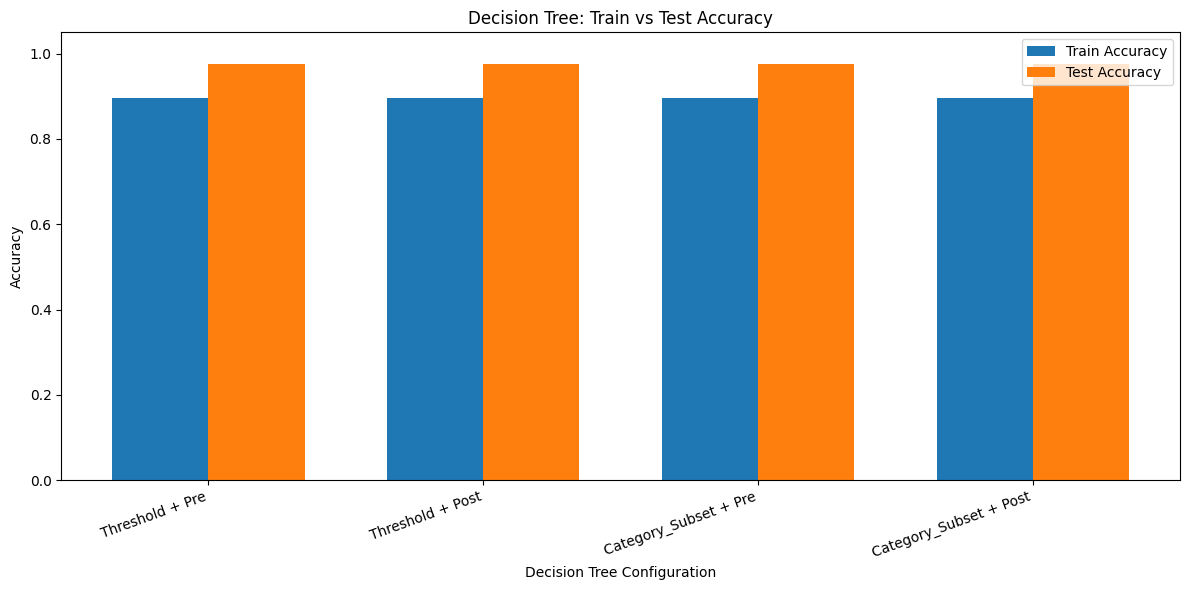

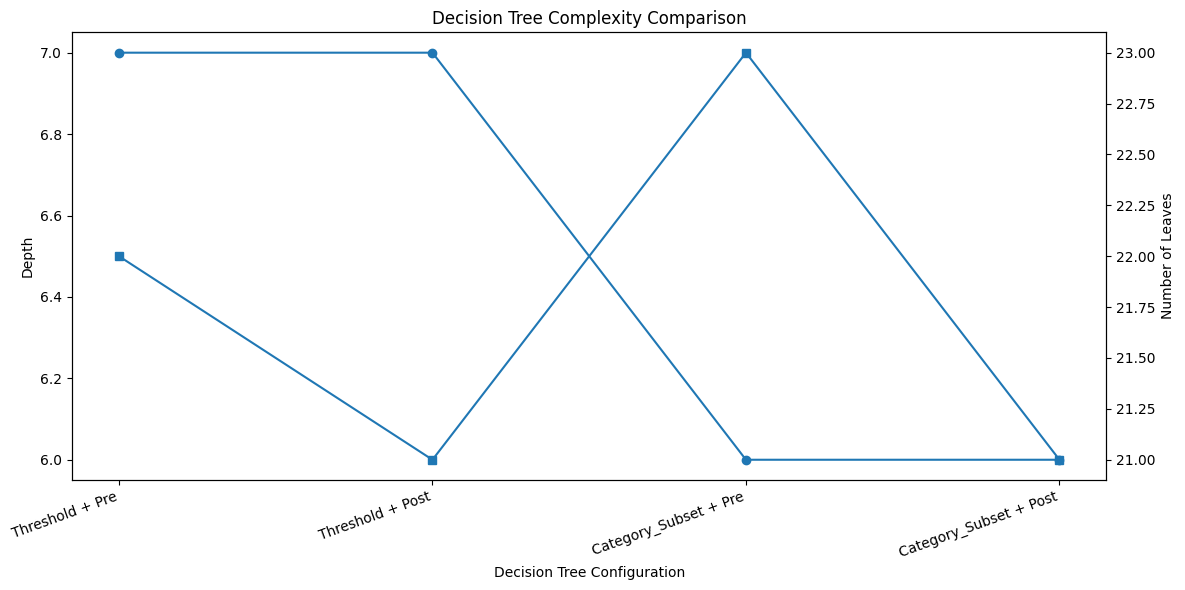

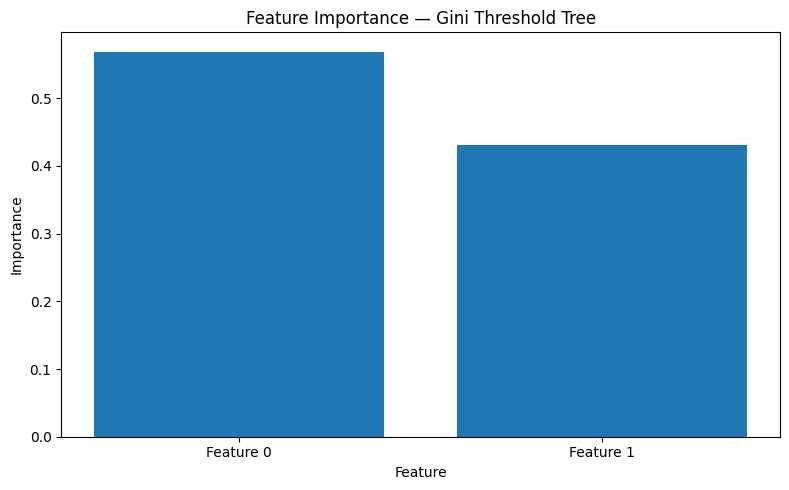

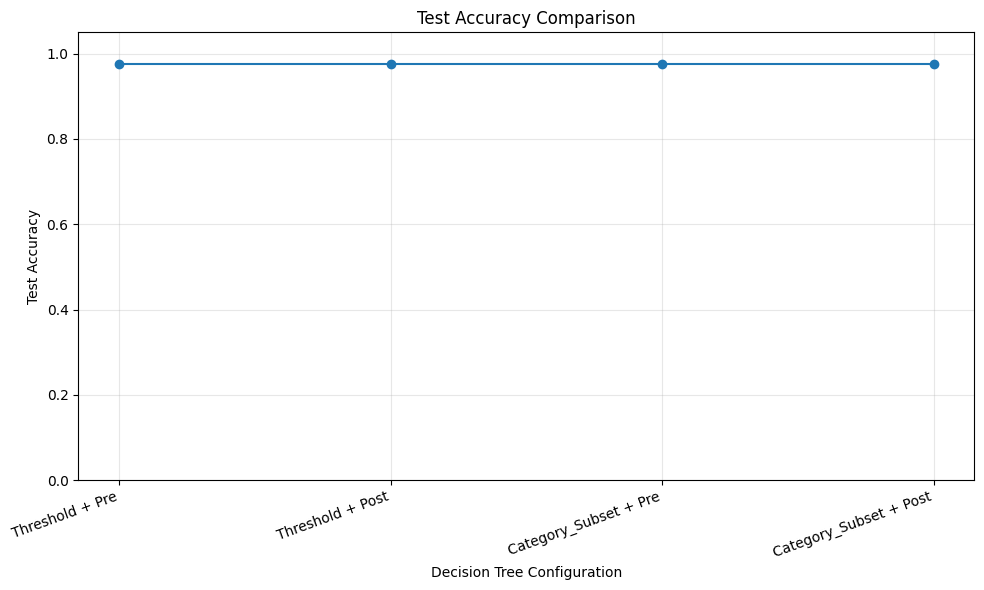

In [ ]:
# Supervised Learning: Decision_Tree_Classification
# GINI
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Tree Node
# ============================================================

class TreeNode:

    def __init__(
        self,
        is_leaf=False,
        prediction=None,
        class_probabilities=None,
        feature_index=None,
        threshold=None,
        category_subset=None,
        left=None,
        right=None,
        impurity=0.0,
        n_samples=0
    ):

        self.is_leaf = is_leaf

        self.prediction = prediction
        self.class_probabilities = class_probabilities

        self.feature_index = feature_index

        # For Threshold split
        self.threshold = threshold

        # For Category_Subset split
        self.category_subset = category_subset

        self.left = left
        self.right = right

        self.impurity = impurity
        self.n_samples = n_samples


# ============================================================
# Decision Tree Classifier
# ============================================================

class DecisionTreeClassifier:

    def __init__(
        self,
        criterion="gini",
        split_strategy="Threshold",
        pruning="Pre",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0,
        random_state=None
    ):

        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf

        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes

        self.min_impurity_decrease = min_impurity_decrease

        self.ccp_alpha = ccp_alpha

        self.random_state = random_state

        self.rng = np.random.default_rng(random_state)

        self.root_ = None

        self.classes_ = None
        self.n_classes_ = None
        self.n_features_in_ = None

        self.feature_importances_ = None

        self.n_leaves_ = 0
        self.tree_depth_ = 0


    # ========================================================
    # Validation
    # ========================================================

    def _validate_parameters(self):

        valid_criteria = [
            "gini"
        ]

        valid_split_strategies = [
            "Threshold",
            "Category_Subset"
        ]

        valid_pruning = [
            "Pre",
            "Post"
        ]

        if self.criterion not in valid_criteria:
            raise ValueError(
                f"Invalid criterion: {self.criterion}"
            )

        if self.split_strategy not in valid_split_strategies:
            raise ValueError(
                f"Invalid split_strategy: {self.split_strategy}"
            )

        if self.pruning not in valid_pruning:
            raise ValueError(
                f"Invalid pruning: {self.pruning}"
            )

        if self.min_samples_split < 2:
            raise ValueError(
                "min_samples_split must be >= 2"
            )

        if self.min_samples_leaf < 1:
            raise ValueError(
                "min_samples_leaf must be >= 1"
            )

        if self.max_depth is not None:
            if self.max_depth < 0:
                raise ValueError(
                    "max_depth must be >= 0"
                )

        if self.max_leaf_nodes is not None:
            if self.max_leaf_nodes < 2:
                raise ValueError(
                    "max_leaf_nodes must be >= 2"
                )

        if self.min_impurity_decrease < 0:
            raise ValueError(
                "min_impurity_decrease must be >= 0"
            )

        if self.ccp_alpha < 0:
            raise ValueError(
                "ccp_alpha must be >= 0"
            )


    # ========================================================
    # Gini Impurity
    # ========================================================

    def _gini(self, y):

        if len(y) == 0:
            return 0.0

        _, counts = np.unique(
            y,
            return_counts=True
        )

        probabilities = counts / len(y)

        return 1.0 - np.sum(
            probabilities ** 2
        )


    # ========================================================
    # General impurity function
    # ========================================================

    def _impurity(self, y):

        if self.criterion == "gini":
            return self._gini(y)

        raise ValueError(
            f"Unknown criterion: {self.criterion}"
        )


    # ========================================================
    # Majority class
    # ========================================================

    def _majority_class(self, y):

        values, counts = np.unique(
            y,
            return_counts=True
        )

        return values[np.argmax(counts)]


    # ========================================================
    # Class probabilities
    # ========================================================

    def _class_probabilities(self, y):

        probabilities = np.zeros(
            self.n_classes_,
            dtype=float
        )

        for i, class_value in enumerate(self.classes_):

            probabilities[i] = np.sum(
                y == class_value
            ) / len(y)

        return probabilities


    # ========================================================
    # Threshold split
    # ========================================================

    def _find_best_threshold_split(
        self,
        X,
        y,
        feature_indices
    ):

        best_gain = -np.inf
        best_feature = None
        best_threshold = None
        best_left = None
        best_right = None

        parent_impurity = self._impurity(y)

        n_samples = len(y)

        for feature_index in feature_indices:

            values = X[:, feature_index]

            # Convert to float
            values = values.astype(float)

            unique_values = np.unique(values)

            if len(unique_values) <= 1:
                continue

            # Midpoints between sorted unique values
            thresholds = (
                unique_values[:-1]
                + unique_values[1:]
            ) / 2.0

            for threshold in thresholds:

                left_mask = values <= threshold
                right_mask = values > threshold

                n_left = np.sum(left_mask)
                n_right = np.sum(right_mask)

                # min_samples_leaf
                if n_left < self.min_samples_leaf:
                    continue

                if n_right < self.min_samples_leaf:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                left_impurity = self._impurity(
                    y_left
                )

                right_impurity = self._impurity(
                    y_right
                )

                weighted_impurity = (
                    (n_left / n_samples)
                    * left_impurity
                    +
                    (n_right / n_samples)
                    * right_impurity
                )

                gain = (
                    parent_impurity
                    - weighted_impurity
                )

                if gain > best_gain:

                    best_gain = gain

                    best_feature = feature_index
                    best_threshold = threshold

                    best_left = left_mask
                    best_right = right_mask

        return (
            best_gain,
            best_feature,
            best_threshold,
            best_left,
            best_right
        )


    # ========================================================
    # Category subset split
    # ========================================================

    def _find_best_category_subset_split(
        self,
        X,
        y,
        feature_indices
    ):

        best_gain = -np.inf
        best_feature = None
        best_subset = None
        best_left = None
        best_right = None

        parent_impurity = self._impurity(y)

        n_samples = len(y)

        for feature_index in feature_indices:

            values = X[:, feature_index]

            categories = np.unique(values)

            n_categories = len(categories)

            if n_categories <= 1:
                continue

            # ------------------------------------------------
            # Exact subset search
            #
            # To avoid duplicate A/B and B/A splits,
            # we force the first category into the left set.
            # ------------------------------------------------

            first_category = categories[0]

            remaining_categories = categories[1:]

            n_subsets = 2 ** len(
                remaining_categories
            )

            for mask_number in range(
                0,
                n_subsets
            ):

                subset = {
                    first_category
                }

                for j, category in enumerate(
                    remaining_categories
                ):

                    if mask_number & (1 << j):

                        subset.add(category)

                # Cannot contain all categories
                if len(subset) == n_categories:
                    continue

                left_mask = np.isin(
                    values,
                    list(subset)
                )

                right_mask = ~left_mask

                n_left = np.sum(left_mask)
                n_right = np.sum(right_mask)

                if n_left < self.min_samples_leaf:
                    continue

                if n_right < self.min_samples_leaf:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                left_impurity = self._impurity(
                    y_left
                )

                right_impurity = self._impurity(
                    y_right
                )

                weighted_impurity = (
                    (n_left / n_samples)
                    * left_impurity
                    +
                    (n_right / n_samples)
                    * right_impurity
                )

                gain = (
                    parent_impurity
                    - weighted_impurity
                )

                if gain > best_gain:

                    best_gain = gain

                    best_feature = feature_index
                    best_subset = set(subset)

                    best_left = left_mask
                    best_right = right_mask

        return (
            best_gain,
            best_feature,
            best_subset,
            best_left,
            best_right
        )


    # ========================================================
    # Select features
    # ========================================================

    def _select_features(self):

        all_features = np.arange(
            self.n_features_in_
        )

        if self.max_features is None:

            return all_features

        if isinstance(
            self.max_features,
            int
        ):

            n_features = min(
                self.max_features,
                self.n_features_in_
            )

        elif isinstance(
            self.max_features,
            float
        ):

            n_features = max(
                1,
                int(
                    self.max_features
                    * self.n_features_in_
                )
            )

        elif self.max_features == "sqrt":

            n_features = max(
                1,
                int(
                    np.sqrt(
                        self.n_features_in_
                    )
                )
            )

        elif self.max_features == "log2":

            n_features = max(
                1,
                int(
                    np.log2(
                        self.n_features_in_
                    )
                )
            )

        else:

            raise ValueError(
                "Invalid max_features"
            )

        return self.rng.choice(
            all_features,
            size=n_features,
            replace=False
        )


    # ========================================================
    # Find best split
    # ========================================================

    def _find_best_split(
        self,
        X,
        y
    ):

        feature_indices = self._select_features()

        if self.split_strategy == "Threshold":

            return self._find_best_threshold_split(
                X,
                y,
                feature_indices
            )

        elif self.split_strategy == "Category_Subset":

            return self._find_best_category_subset_split(
                X,
                y,
                feature_indices
            )

        raise ValueError(
            "Invalid split strategy"
        )


    # ========================================================
    # Build tree
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth
    ):

        n_samples = len(y)

        impurity = self._impurity(y)

        prediction = self._majority_class(y)

        probabilities = self._class_probabilities(y)

        # ----------------------------------------------------
        # Create leaf by default
        # ----------------------------------------------------

        node = TreeNode(
            is_leaf=True,
            prediction=prediction,
            class_probabilities=probabilities,
            impurity=impurity,
            n_samples=n_samples
        )

        self.n_leaves_ += 1

        self.tree_depth_ = max(
            self.tree_depth_,
            depth
        )

        # ----------------------------------------------------
        # Pure node
        # ----------------------------------------------------

        if impurity == 0.0:

            return node

        # ----------------------------------------------------
        # max_depth
        # ----------------------------------------------------

        if self.max_depth is not None:

            if depth >= self.max_depth:

                return node

        # ----------------------------------------------------
        # min_samples_split
        # ----------------------------------------------------

        if n_samples < self.min_samples_split:

            return node

        # ----------------------------------------------------
        # max_leaf_nodes
        # ----------------------------------------------------

        if self.max_leaf_nodes is not None:

            if self.n_leaves_ >= self.max_leaf_nodes:

                return node

        # ----------------------------------------------------
        # Find best split
        # ----------------------------------------------------

        result = self._find_best_split(
            X,
            y
        )

        gain = result[0]

        if gain == -np.inf:

            return node

        # ----------------------------------------------------
        # min_impurity_decrease
        # ----------------------------------------------------

        if gain < self.min_impurity_decrease:

            return node

        feature_index = result[1]

        split_value = result[2]

        left_mask = result[3]

        right_mask = result[4]

        if feature_index is None:

            return node

        if left_mask is None or right_mask is None:

            return node

        # ----------------------------------------------------
        # Create child datasets
        # ----------------------------------------------------

        X_left = X[left_mask]
        y_left = y[left_mask]

        X_right = X[right_mask]
        y_right = y[right_mask]

        if len(y_left) < self.min_samples_leaf:

            return node

        if len(y_right) < self.min_samples_leaf:

            return node

        # ----------------------------------------------------
        # Feature importance
        # ----------------------------------------------------

        weighted_child_impurity = (
            (len(y_left) / n_samples)
            * self._impurity(y_left)
            +
            (len(y_right) / n_samples)
            * self._impurity(y_right)
        )

        impurity_reduction = (
            impurity
            - weighted_child_impurity
        )

        self._feature_importance_raw[
            feature_index
        ] += (
            n_samples
            * impurity_reduction
        )

        # ----------------------------------------------------
        # Current node becomes internal node
        # ----------------------------------------------------

        self.n_leaves_ -= 1

        node.is_leaf = False

        node.feature_index = feature_index

        # ----------------------------------------------------
        # Threshold split
        # ----------------------------------------------------

        if self.split_strategy == "Threshold":

            node.threshold = split_value

        # ----------------------------------------------------
        # Category subset split
        # ----------------------------------------------------

        elif self.split_strategy == "Category_Subset":

            node.category_subset = split_value

        # ----------------------------------------------------
        # Recursively create children
        # ----------------------------------------------------

        node.left = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        node.right = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return node


    # ========================================================
    # Post pruning
    # ========================================================

    def _post_prune(
        self,
        node
    ):

        if node.is_leaf:

            leaf_risk = (
                node.n_samples
                * node.impurity
            )

            return (
                leaf_risk,
                1
            )

        # ----------------------------------------------------
        # Recursively prune children first
        # ----------------------------------------------------

        left_risk, left_leaves = (
            self._post_prune(node.left)
        )

        right_risk, right_leaves = (
            self._post_prune(node.right)
        )

        subtree_risk = (
            left_risk
            + right_risk
        )

        subtree_leaves = (
            left_leaves
            + right_leaves
        )

        # ----------------------------------------------------
        # Cost complexity of subtree
        # ----------------------------------------------------

        subtree_cost = (
            subtree_risk
            + self.ccp_alpha
            * subtree_leaves
        )

        # ----------------------------------------------------
        # Cost if current node becomes leaf
        # ----------------------------------------------------

        node_leaf_risk = (
            node.n_samples
            * node.impurity
        )

        leaf_cost = (
            node_leaf_risk
            + self.ccp_alpha
        )

        # ----------------------------------------------------
        # Prune
        # ----------------------------------------------------

        if leaf_cost <= subtree_cost:

            node.is_leaf = True

            node.feature_index = None
            node.threshold = None
            node.category_subset = None

            node.left = None
            node.right = None

            return (
                node_leaf_risk,
                1
            )

        return (
            subtree_risk,
            subtree_leaves
        )


    # ========================================================
    # Recalculate tree statistics
    # ========================================================

    def _calculate_tree_statistics(
        self,
        node,
        depth=0
    ):

        if node is None:

            return 0, 0

        if node.is_leaf:

            return 1, depth

        left_leaves, left_depth = (
            self._calculate_tree_statistics(
                node.left,
                depth + 1
            )
        )

        right_leaves, right_depth = (
            self._calculate_tree_statistics(
                node.right,
                depth + 1
            )
        )

        leaves = (
            left_leaves
            + right_leaves
        )

        maximum_depth = max(
            left_depth,
            right_depth
        )

        return (
            leaves,
            maximum_depth
        )


    # ========================================================
    # Fit
    # ========================================================

    def fit(
        self,
        X,
        y
    ):

        self._validate_parameters()

        X = np.asarray(X)

        y = np.asarray(y)

        if X.ndim != 2:

            raise ValueError(
                "X must be 2-dimensional"
            )

        if y.ndim != 1:

            raise ValueError(
                "y must be 1-dimensional"
            )

        if len(X) != len(y):

            raise ValueError(
                "X and y have different lengths"
            )

        self.n_features_in_ = X.shape[1]

        self.classes_ = np.unique(y)

        self.n_classes_ = len(
            self.classes_
        )

        self._feature_importance_raw = np.zeros(
            self.n_features_in_,
            dtype=float
        )

        self.n_leaves_ = 0
        self.tree_depth_ = 0

        # ----------------------------------------------------
        # Build tree
        # ----------------------------------------------------

        self.root_ = self._build_tree(
            X,
            y,
            depth=0
        )

        # ----------------------------------------------------
        # Post pruning
        # ----------------------------------------------------

        if self.pruning == "Post":

            self._post_prune(
                self.root_
            )

        # ----------------------------------------------------
        # Recalculate statistics
        # ----------------------------------------------------

        (
            self.n_leaves_,
            self.tree_depth_
        ) = self._calculate_tree_statistics(
            self.root_
        )

        # ----------------------------------------------------
        # Feature importance
        # ----------------------------------------------------

        total = np.sum(
            self._feature_importance_raw
        )

        if total > 0:

            self.feature_importances_ = (
                self._feature_importance_raw
                / total
            )

        else:

            self.feature_importances_ = np.zeros(
                self.n_features_in_
            )

        return self


    # ========================================================
    # Predict one sample
    # ========================================================

    def _predict_one(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.prediction

        feature_value = x[
            node.feature_index
        ]

        # ----------------------------------------------------
        # Threshold
        # ----------------------------------------------------

        if self.split_strategy == "Threshold":

            if float(feature_value) <= node.threshold:

                return self._predict_one(
                    x,
                    node.left
                )

            else:

                return self._predict_one(
                    x,
                    node.right
                )

        # ----------------------------------------------------
        # Category subset
        # ----------------------------------------------------

        elif self.split_strategy == "Category_Subset":

            if feature_value in node.category_subset:

                return self._predict_one(
                    x,
                    node.left
                )

            else:

                return self._predict_one(
                    x,
                    node.right
                )


    # ========================================================
    # Predict
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(X)

        predictions = []

        for x in X:

            predictions.append(
                self._predict_one(
                    x,
                    self.root_
                )
            )

        return np.asarray(
            predictions
        )


    # ========================================================
    # Predict probabilities
    # ========================================================

    def _predict_proba_one(
        self,
        x,
        node
    ):

        if node.is_leaf:

            return node.class_probabilities

        feature_value = x[
            node.feature_index
        ]

        if self.split_strategy == "Threshold":

            if float(feature_value) <= node.threshold:

                return self._predict_proba_one(
                    x,
                    node.left
                )

            else:

                return self._predict_proba_one(
                    x,
                    node.right
                )

        elif self.split_strategy == "Category_Subset":

            if feature_value in node.category_subset:

                return self._predict_proba_one(
                    x,
                    node.left
                )

            else:

                return self._predict_proba_one(
                    x,
                    node.right
                )


    def predict_proba(
        self,
        X
    ):

        X = np.asarray(X)

        probabilities = []

        for x in X:

            probabilities.append(
                self._predict_proba_one(
                    x,
                    self.root_
                )
            )

        return np.asarray(
            probabilities
        )


    # ========================================================
    # Accuracy score
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        y_pred = self.predict(X)

        return np.mean(
            y_pred == y
        )


    # ========================================================
    # Print tree
    # ========================================================

    def _print_tree(
        self,
        node,
        depth=0
    ):

        indent = "    " * depth

        if node.is_leaf:

            print(
                indent
                + f"Leaf: class={node.prediction}, "
                + f"samples={node.n_samples}"
            )

            return

        if self.split_strategy == "Threshold":

            print(
                indent
                + f"X[{node.feature_index}] "
                + f"<= {node.threshold:.4f}"
            )

        elif self.split_strategy == "Category_Subset":

            print(
                indent
                + f"X[{node.feature_index}] "
                + f"in {node.category_subset}"
            )

        self._print_tree(
            node.left,
            depth + 1
        )

        self._print_tree(
            node.right,
            depth + 1
        )


    def print_tree(self):

        self._print_tree(
            self.root_
        )


# ============================================================
# Train/Test Split from scratch
# ============================================================

def train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=None
):

    X = np.asarray(X)

    y = np.asarray(y)

    rng = np.random.default_rng(
        random_state
    )

    indices = np.arange(
        len(X)
    )

    rng.shuffle(indices)

    test_count = int(
        len(X)
        * test_size
    )

    test_indices = indices[
        :test_count
    ]

    train_indices = indices[
        test_count:
    ]

    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices]
    )


# ============================================================
# Example dataset
# ============================================================
#
# We use integer-valued categories.
#
# This lets us demonstrate BOTH:
#
# Threshold:
#       X <= threshold
#
# Category_Subset:
#       X in {category1, category2}
#
# ============================================================

rng = np.random.default_rng(42)

n_samples = 400

X = rng.integers(
    0,
    5,
    size=(n_samples, 2)
)

# Nonlinear classification problem
y = (
    (
        (X[:, 0] == 0)
        |
        (X[:, 0] == 1)
    )
    &
    (
        X[:, 1] >= 2
    )
).astype(int)

# Add some noise
noise_indices = rng.choice(
    n_samples,
    size=35,
    replace=False
)

y[noise_indices] = (
    1 - y[noise_indices]
)


# ============================================================
# Train/Test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# Four requested configurations
# ============================================================

models = {

    "Threshold + Pre":
        DecisionTreeClassifier(
            criterion="gini",
            split_strategy="Threshold",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),

    "Threshold + Post":
        DecisionTreeClassifier(
            criterion="gini",
            split_strategy="Threshold",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.02,
            random_state=42
        ),

    "Category_Subset + Pre":
        DecisionTreeClassifier(
            criterion="gini",
            split_strategy="Category_Subset",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),

    "Category_Subset + Post":
        DecisionTreeClassifier(
            criterion="gini",
            split_strategy="Category_Subset",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.02,
            random_state=42
        )
}


# ============================================================
# Train all models
# ============================================================

results = {}

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    train_accuracy = model.score(
        X_train,
        y_train
    )

    test_accuracy = model.score(
        X_test,
        y_test
    )

    results[name] = {
        "model": model,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "depth": model.tree_depth_,
        "leaves": model.n_leaves_
    }


# ============================================================
# Print comparison
# ============================================================

print()
print("=" * 90)
print(
    f"{'Configuration':30s}"
    f"{'Train Acc':>15s}"
    f"{'Test Acc':>15s}"
    f"{'Depth':>10s}"
    f"{'Leaves':>10s}"
)
print("=" * 90)

for name, result in results.items():

    print(
        f"{name:30s}"
        f"{result['train_accuracy']:>15.4f}"
        f"{result['test_accuracy']:>15.4f}"
        f"{result['depth']:>10d}"
        f"{result['leaves']:>10d}"
    )

print("=" * 90)


# ============================================================
# Figure 1
# Train vs Test Accuracy
# ============================================================

names = list(results.keys())

train_scores = [
    results[name]["train_accuracy"]
    for name in names
]

test_scores = [
    results[name]["test_accuracy"]
    for name in names
]

x = np.arange(
    len(names)
)

width = 0.35

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    x - width / 2,
    train_scores,
    width,
    label="Train Accuracy"
)

plt.bar(
    x + width / 2,
    test_scores,
    width,
    label="Test Accuracy"
)

plt.xticks(
    x,
    names,
    rotation=20,
    ha="right"
)

plt.ylabel(
    "Accuracy"
)

plt.xlabel(
    "Decision Tree Configuration"
)

plt.title(
    "Decision Tree: Train vs Test Accuracy"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# Figure 2
# Tree Complexity
# ============================================================

depths = [
    results[name]["depth"]
    for name in names
]

leaves = [
    results[name]["leaves"]
    for name in names
]

fig, ax1 = plt.subplots(
    figsize=(12, 6)
)

ax1.plot(
    x,
    depths,
    marker="o",
    label="Tree Depth"
)

ax1.set_xlabel(
    "Decision Tree Configuration"
)

ax1.set_ylabel(
    "Depth"
)

ax1.set_xticks(
    x
)

ax1.set_xticklabels(
    names,
    rotation=20,
    ha="right"
)

ax2 = ax1.twinx()

ax2.plot(
    x,
    leaves,
    marker="s",
    label="Number of Leaves"
)

ax2.set_ylabel(
    "Number of Leaves"
)

plt.title(
    "Decision Tree Complexity Comparison"
)

fig.tight_layout()

plt.show()


# ============================================================
# Figure 3
# Feature Importance
# ============================================================

threshold_pre_model = results[
    "Threshold + Pre"
]["model"]

feature_importances = (
    threshold_pre_model.feature_importances_
)

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    np.arange(
        len(feature_importances)
    ),
    feature_importances
)

plt.xticks(
    np.arange(
        len(feature_importances)
    ),
    [
        f"Feature {i}"
        for i in range(
            len(feature_importances)
        )
    ]
)

plt.ylabel(
    "Importance"
)

plt.xlabel(
    "Feature"
)

plt.title(
    "Feature Importance — Gini Threshold Tree"
)

plt.tight_layout()

plt.show()


# ============================================================
# Figure 4
# Test Accuracy Comparison
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    names,
    test_scores,
    marker="o"
)

plt.ylabel(
    "Test Accuracy"
)

plt.xlabel(
    "Decision Tree Configuration"
)

plt.title(
    "Test Accuracy Comparison"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


              ENTROPY DECISION TREE RESULTS

----------------------------------------------------------------------
                    MODEL COMPARISON
----------------------------------------------------------------------
Model                                   Accuracy     Depth    Leaves
----------------------------------------------------------------------
Entropy + Threshold + Pre                 1.0000         7        13
Entropy + Threshold + Post                1.0000         7        13
Entropy + Category_Subset + Pre           0.7733         4        13
Entropy + Category_Subset + Post          0.7733         4        13
----------------------------------------------------------------------


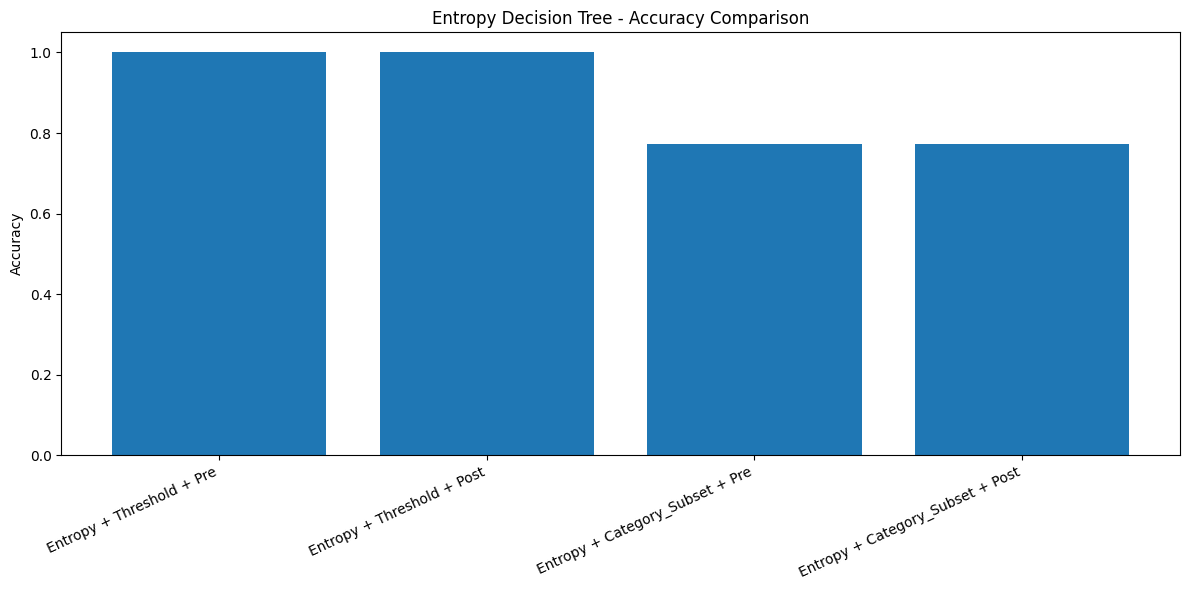

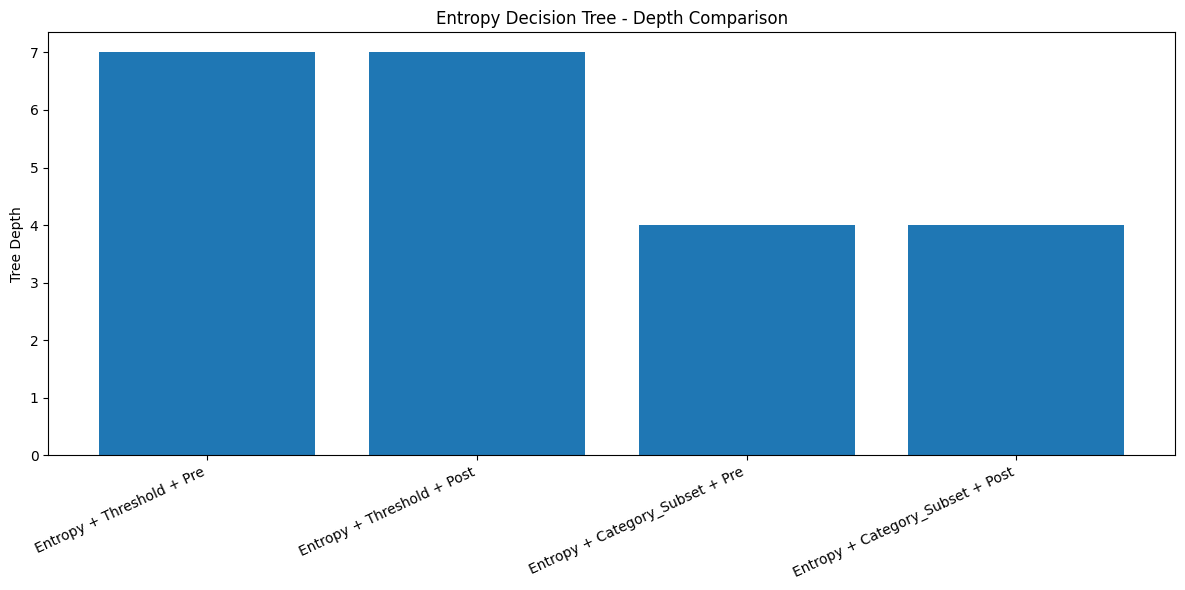

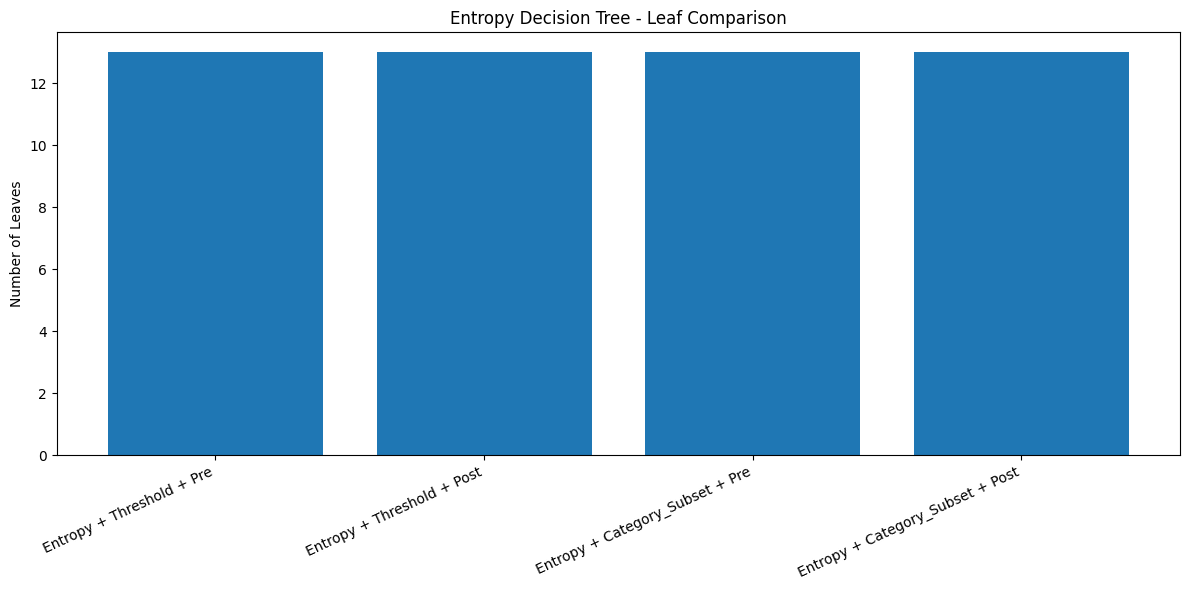

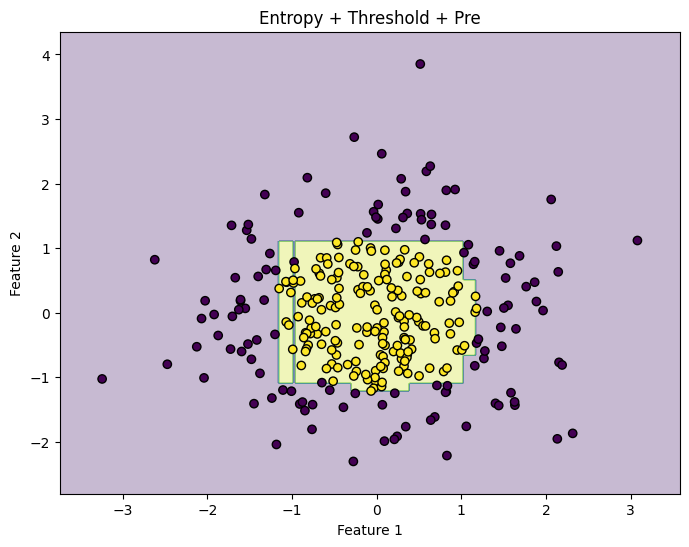

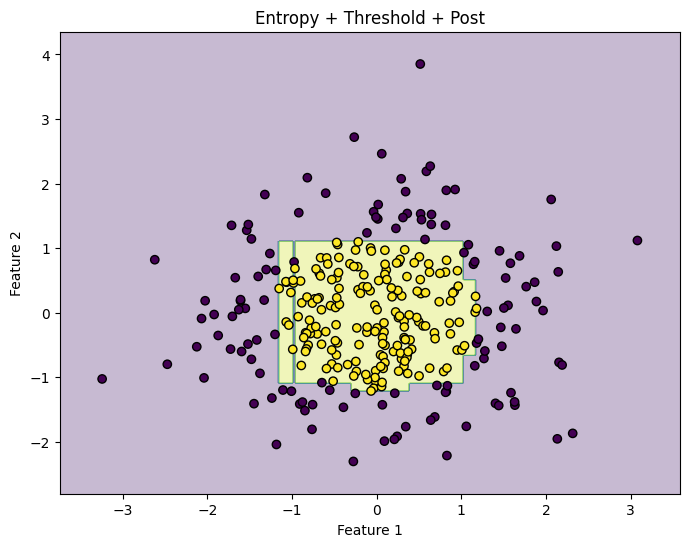

In [ ]:
#Entropy
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations


class DecisionTreeClassifier:
    def __init__(
        self,
        criterion="entropy",
        split_strategy="Threshold",
        pruning="Pre",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0,
        random_state=None
    ):

        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes
        self.min_impurity_decrease = min_impurity_decrease
        self.ccp_alpha = ccp_alpha
        self.random_state = random_state

        self.root_ = None
        self.n_leaves_ = 0
        self.tree_depth_ = 0

        self.rng_ = np.random.RandomState(random_state)

        self._validate_parameters()

    # ---------------------------------------------------------
    # Parameter validation
    # ---------------------------------------------------------

    def _validate_parameters(self):

        if self.criterion != "entropy":
            raise ValueError(
                "For this implementation criterion must be 'entropy'."
            )

        if self.split_strategy not in [
            "Threshold",
            "Category_Subset"
        ]:
            raise ValueError(
                "split_strategy must be 'Threshold' or 'Category_Subset'."
            )

        if self.pruning not in ["Pre", "Post"]:
            raise ValueError(
                "pruning must be 'Pre' or 'Post'."
            )

        if self.min_samples_split < 2:
            raise ValueError(
                "min_samples_split must be >= 2."
            )

        if self.min_samples_leaf < 1:
            raise ValueError(
                "min_samples_leaf must be >= 1."
            )

        if self.max_depth is not None and self.max_depth < 0:
            raise ValueError(
                "max_depth must be >= 0 or None."
            )

        if self.max_leaf_nodes is not None:
            if self.max_leaf_nodes < 1:
                raise ValueError(
                    "max_leaf_nodes must be >= 1."
                )

        if self.min_impurity_decrease < 0:
            raise ValueError(
                "min_impurity_decrease must be >= 0."
            )

        if self.ccp_alpha < 0:
            raise ValueError(
                "ccp_alpha must be >= 0."
            )

    # ---------------------------------------------------------
    # Entropy
    # ---------------------------------------------------------

    def _entropy(self, y):

        if len(y) == 0:
            return 0.0

        _, counts = np.unique(y, return_counts=True)

        probabilities = counts / len(y)

        entropy = 0.0

        for p in probabilities:
            if p > 0:
                entropy -= p * np.log2(p)

        return entropy

    # ---------------------------------------------------------
    # Information Gain
    # ---------------------------------------------------------

    def _information_gain(self, y, left_y, right_y):

        parent_entropy = self._entropy(y)

        n = len(y)
        n_left = len(left_y)
        n_right = len(right_y)

        if n_left == 0 or n_right == 0:
            return 0.0

        weighted_entropy = (
            (n_left / n) * self._entropy(left_y)
            +
            (n_right / n) * self._entropy(right_y)
        )

        return parent_entropy - weighted_entropy

    # ---------------------------------------------------------
    # Majority class
    # ---------------------------------------------------------

    def _majority_class(self, y):

        classes, counts = np.unique(y, return_counts=True)

        return classes[np.argmax(counts)]

    # ---------------------------------------------------------
    # Feature selection
    # ---------------------------------------------------------

    def _select_features(self, n_features):

        if self.max_features is None:
            return np.arange(n_features)

        if isinstance(self.max_features, int):

            k = min(self.max_features, n_features)

        elif isinstance(self.max_features, float):

            k = max(
                1,
                int(self.max_features * n_features)
            )

        else:

            raise ValueError(
                "max_features must be None, int, or float."
            )

        return self.rng_.choice(
            n_features,
            size=k,
            replace=False
        )

    # ---------------------------------------------------------
    # Threshold split
    # ---------------------------------------------------------

    def _find_threshold_split(self, X, y, feature):

        values = X[:, feature]

        try:
            values_numeric = values.astype(float)
        except (ValueError, TypeError):

            raise ValueError(
                "Threshold split requires numerical features."
            )

        unique_values = np.unique(values_numeric)

        if len(unique_values) <= 1:
            return None

        thresholds = (
            unique_values[:-1]
            + unique_values[1:]
        ) / 2.0

        best_gain = -np.inf
        best_threshold = None
        best_left = None
        best_right = None

        for threshold in thresholds:

            left_mask = values_numeric <= threshold
            right_mask = values_numeric > threshold

            left_count = np.sum(left_mask)
            right_count = np.sum(right_mask)

            if left_count < self.min_samples_leaf:
                continue

            if right_count < self.min_samples_leaf:
                continue

            left_y = y[left_mask]
            right_y = y[right_mask]

            gain = self._information_gain(
                y,
                left_y,
                right_y
            )

            if gain > best_gain:

                best_gain = gain
                best_threshold = threshold
                best_left = left_mask
                best_right = right_mask

        if best_threshold is None:
            return None

        return {
            "feature": feature,
            "type": "threshold",
            "threshold": best_threshold,
            "left_mask": best_left,
            "right_mask": best_right,
            "gain": best_gain
        }

    # ---------------------------------------------------------
    # Generate category subsets
    # ---------------------------------------------------------

    def _category_subsets(self, values):

        categories = list(np.unique(values))

        n_categories = len(categories)

        if n_categories <= 1:
            return []

        subsets = []

        # Avoid duplicate A/B and B/A splits
        max_size = n_categories // 2

        for size in range(1, max_size + 1):

            for subset in combinations(
                categories,
                size
            ):

                subset = set(subset)

                # Symmetry breaking
                if categories[0] not in subset:
                    continue

                subsets.append(subset)

        return subsets

    # ---------------------------------------------------------
    # Category subset split
    # ---------------------------------------------------------

    def _find_category_subset_split(
        self,
        X,
        y,
        feature
    ):

        values = X[:, feature]

        subsets = self._category_subsets(values)

        if len(subsets) == 0:
            return None

        best_gain = -np.inf
        best_subset = None
        best_left = None
        best_right = None

        for subset in subsets:

            left_mask = np.array([
                value in subset
                for value in values
            ])

            right_mask = ~left_mask

            left_count = np.sum(left_mask)
            right_count = np.sum(right_mask)

            if left_count < self.min_samples_leaf:
                continue

            if right_count < self.min_samples_leaf:
                continue

            left_y = y[left_mask]
            right_y = y[right_mask]

            gain = self._information_gain(
                y,
                left_y,
                right_y
            )

            if gain > best_gain:

                best_gain = gain
                best_subset = subset
                best_left = left_mask
                best_right = right_mask

        if best_subset is None:
            return None

        return {
            "feature": feature,
            "type": "category_subset",
            "subset": best_subset,
            "left_mask": best_left,
            "right_mask": best_right,
            "gain": best_gain
        }

    # ---------------------------------------------------------
    # Find best split
    # ---------------------------------------------------------

    def _find_best_split(self, X, y):

        n_features = X.shape[1]

        feature_indices = self._select_features(
            n_features
        )

        best_split = None
        best_gain = -np.inf

        for feature in feature_indices:

            if self.split_strategy == "Threshold":

                split = self._find_threshold_split(
                    X,
                    y,
                    feature
                )

            else:

                split = self._find_category_subset_split(
                    X,
                    y,
                    feature
                )

            if split is None:
                continue

            if split["gain"] > best_gain:

                best_gain = split["gain"]
                best_split = split

        return best_split

    # ---------------------------------------------------------
    # Build tree
    # ---------------------------------------------------------

    def _build_tree(
        self,
        X,
        y,
        depth
    ):

        node = {
            "is_leaf": False,
            "prediction": self._majority_class(y),
            "depth": depth,
            "n_samples": len(y),
            "impurity": self._entropy(y),
            "left": None,
            "right": None,
            "feature": None,
            "split_type": None,
            "threshold": None,
            "subset": None,
            "gain": 0.0
        }

        self.tree_depth_ = max(
            self.tree_depth_,
            depth
        )

        # -----------------------------------------------------
        # Stopping conditions
        # -----------------------------------------------------

        if len(np.unique(y)) == 1:

            node["is_leaf"] = True
            self.n_leaves_ += 1

            return node

        if len(y) < self.min_samples_split:

            node["is_leaf"] = True
            self.n_leaves_ += 1

            return node

        if self.max_depth is not None:

            if depth >= self.max_depth:

                node["is_leaf"] = True
                self.n_leaves_ += 1

                return node

        # -----------------------------------------------------
        # Find split
        # -----------------------------------------------------

        split = self._find_best_split(X, y)

        if split is None:

            node["is_leaf"] = True
            self.n_leaves_ += 1

            return node

        # -----------------------------------------------------
        # Pre-pruning: minimum impurity decrease
        # -----------------------------------------------------

        if (
            self.pruning == "Pre"
            and split["gain"] < self.min_impurity_decrease
        ):

            node["is_leaf"] = True
            self.n_leaves_ += 1

            return node

        # -----------------------------------------------------
        # max_leaf_nodes
        # -----------------------------------------------------

        if self.max_leaf_nodes is not None:

            if self.n_leaves_ + 1 >= self.max_leaf_nodes:

                node["is_leaf"] = True
                self.n_leaves_ += 1

                return node

        # -----------------------------------------------------
        # Store split
        # -----------------------------------------------------

        node["feature"] = split["feature"]
        node["split_type"] = split["type"]
        node["gain"] = split["gain"]

        if split["type"] == "threshold":

            node["threshold"] = split["threshold"]

        else:

            node["subset"] = split["subset"]

        left_mask = split["left_mask"]
        right_mask = split["right_mask"]

        X_left = X[left_mask]
        y_left = y[left_mask]

        X_right = X[right_mask]
        y_right = y[right_mask]

        # -----------------------------------------------------
        # Recursive construction
        # -----------------------------------------------------

        node["left"] = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        node["right"] = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return node

    # ---------------------------------------------------------
    # Cost complexity pruning
    # ---------------------------------------------------------

    def _subtree_cost(self, node):

        if node["is_leaf"]:

            return (
                node["n_samples"]
                * node["impurity"]
                + self.ccp_alpha
            )

        left_cost = self._subtree_cost(
            node["left"]
        )

        right_cost = self._subtree_cost(
            node["right"]
        )

        return left_cost + right_cost

    # ---------------------------------------------------------
    # Post pruning
    # ---------------------------------------------------------

    def _post_prune(self, node):

        if node is None or node["is_leaf"]:
            return

        self._post_prune(node["left"])
        self._post_prune(node["right"])

        left = node["left"]
        right = node["right"]

        subtree_cost = (
            self._subtree_cost(left)
            +
            self._subtree_cost(right)
        )

        leaf_cost = (
            node["n_samples"]
            * node["impurity"]
            +
            self.ccp_alpha
        )

        if leaf_cost <= subtree_cost:

            node["is_leaf"] = True

            node["left"] = None
            node["right"] = None

            node["feature"] = None
            node["split_type"] = None
            node["threshold"] = None
            node["subset"] = None

    # ---------------------------------------------------------
    # Count leaves
    # ---------------------------------------------------------

    def _count_leaves(self, node):

        if node is None:
            return 0

        if node["is_leaf"]:
            return 1

        return (
            self._count_leaves(node["left"])
            +
            self._count_leaves(node["right"])
        )

    # ---------------------------------------------------------
    # Fit
    # ---------------------------------------------------------

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim != 2:
            raise ValueError(
                "X must be a 2-dimensional array."
            )

        if y.ndim != 1:
            y = y.ravel()

        if len(X) != len(y):
            raise ValueError(
                "X and y must have same number of samples."
            )

        self.classes_ = np.unique(y)

        self.n_features_in_ = X.shape[1]

        self.n_leaves_ = 0
        self.tree_depth_ = 0

        self.root_ = self._build_tree(
            X,
            y,
            depth=0
        )

        # -----------------------------------------------------
        # Post pruning
        # -----------------------------------------------------

        if self.pruning == "Post":

            self._post_prune(
                self.root_
            )

            self.n_leaves_ = self._count_leaves(
                self.root_
            )

        return self

    # ---------------------------------------------------------
    # Prediction for one sample
    # ---------------------------------------------------------

    def _predict_one(self, x, node):

        if node["is_leaf"]:
            return node["prediction"]

        feature = node["feature"]

        if node["split_type"] == "threshold":

            try:
                value = float(x[feature])
            except (ValueError, TypeError):

                raise ValueError(
                    "Threshold prediction requires numerical features."
                )

            if value <= node["threshold"]:

                return self._predict_one(
                    x,
                    node["left"]
                )

            else:

                return self._predict_one(
                    x,
                    node["right"]
                )

        else:

            if x[feature] in node["subset"]:

                return self._predict_one(
                    x,
                    node["left"]
                )

            else:

                return self._predict_one(
                    x,
                    node["right"]
                )

    # ---------------------------------------------------------
    # Predict
    # ---------------------------------------------------------

    def predict(self, X):

        X = np.asarray(X)

        return np.array([
            self._predict_one(
                x,
                self.root_
            )
            for x in X
        ])

    # ---------------------------------------------------------
    # Score
    # ---------------------------------------------------------

    def score(self, X, y):

        y = np.asarray(y)

        y_pred = self.predict(X)

        return np.mean(
            y_pred == y
        )


#==================================================
#     Numerical Dataset for Threshold Trees
#==================================================

np.random.seed(42)

X = np.random.randn(300, 2)

y = (
    (X[:, 0] ** 2 + X[:, 1] ** 2 < 1.5)
    .astype(int)
)


#==================================================
#     Train Entropy + Threshold + Pre
#==================================================

tree_entropy_threshold_pre = DecisionTreeClassifier(
    criterion="entropy",
    split_strategy="Threshold",
    pruning="Pre",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    random_state=42
)

tree_entropy_threshold_pre.fit(X, y)


#==================================================
#     Train Entropy + Threshold + Post
#==================================================

tree_entropy_threshold_post = DecisionTreeClassifier(
    criterion="entropy",
    split_strategy="Threshold",
    pruning="Post",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.01,
    random_state=42
)

tree_entropy_threshold_post.fit(X, y)


#==================================================
#     Create Categorical Dataset
#==================================================

X_category = np.empty_like(X, dtype=object)

X_category[:, 0] = np.where(
    X[:, 0] < -0.75,
    "Very_Low",
    np.where(
        X[:, 0] < 0,
        "Low",
        np.where(
            X[:, 0] < 0.75,
            "High",
            "Very_High"
        )
    )
)

X_category[:, 1] = np.where(
    X[:, 1] < -0.75,
    "Very_Low",
    np.where(
        X[:, 1] < 0,
        "Low",
        np.where(
            X[:, 1] < 0.75,
            "High",
            "Very_High"
        )
    )
)


#==================================================
#     Entropy + Category_Subset + Pre
#==================================================

tree_entropy_category_pre = DecisionTreeClassifier(
    criterion="entropy",
    split_strategy="Category_Subset",
    pruning="Pre",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    random_state=42
)

tree_entropy_category_pre.fit(
    X_category,
    y
)


#==================================================
#     Entropy + Category_Subset + Post
#==================================================

tree_entropy_category_post = DecisionTreeClassifier(
    criterion="entropy",
    split_strategy="Category_Subset",
    pruning="Post",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.01,
    random_state=42
)

tree_entropy_category_post.fit(
    X_category,
    y
)


#==================================================
#     Train All Four Together
#==================================================

models = {

    "Entropy + Threshold + Pre":
        tree_entropy_threshold_pre,

    "Entropy + Threshold + Post":
        tree_entropy_threshold_post,

    "Entropy + Category_Subset + Pre":
        tree_entropy_category_pre,

    "Entropy + Category_Subset + Post":
        tree_entropy_category_post
}


#==================================================
#       Readable Results
#==================================================

print("\n" + "=" * 70)
print("              ENTROPY DECISION TREE RESULTS")
print("=" * 70)

results = []

for name, model in models.items():

    if "Category_Subset" in name:
        accuracy = model.score(
            X_category,
            y
        )

    else:
        accuracy = model.score(
            X,
            y
        )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Depth": model.tree_depth_,
        "Leaves": model.n_leaves_
    })


#==================================================
#       Comparison Table
#==================================================

print("\n" + "-" * 70)
print("                    MODEL COMPARISON")
print("-" * 70)

print(
    f"{'Model':<38}"
    f"{'Accuracy':>10}"
    f"{'Depth':>10}"
    f"{'Leaves':>10}"
)

print("-" * 70)

for result in results:

    print(
        f"{result['Model']:<38}"
        f"{result['Accuracy']:>10.4f}"
        f"{result['Depth']:>10}"
        f"{result['Leaves']:>10}"
    )

print("-" * 70)


#==================================================
#     Comparison Plot — Accuracy
#==================================================

names = []
accuracies = []

for name, model in models.items():

    if "Category_Subset" in name:

        accuracy = model.score(
            X_category,
            y
        )

    else:

        accuracy = model.score(
            X,
            y
        )

    names.append(name)
    accuracies.append(accuracy)


plt.figure(figsize=(12, 6))

plt.bar(
    range(len(names)),
    accuracies
)

plt.xticks(
    range(len(names)),
    names,
    rotation=25,
    ha="right"
)

plt.ylabel("Accuracy")
plt.title(
    "Entropy Decision Tree - Accuracy Comparison"
)

plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()


#==================================================
#     Comparison Plot — Tree Depth
#==================================================

depths = [
    model.tree_depth_
    for model in models.values()
]

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(names)),
    depths
)

plt.xticks(
    range(len(names)),
    names,
    rotation=25,
    ha="right"
)

plt.ylabel("Tree Depth")
plt.title(
    "Entropy Decision Tree - Depth Comparison"
)

plt.tight_layout()
plt.show()


#==================================================
#     Comparison Plot — Number of Leaves
#==================================================

leaves = [
    model.n_leaves_
    for model in models.values()
]

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(names)),
    leaves
)

plt.xticks(
    range(len(names)),
    names,
    rotation=25,
    ha="right"
)

plt.ylabel("Number of Leaves")
plt.title(
    "Entropy Decision Tree - Leaf Comparison"
)

plt.tight_layout()
plt.show()


#==================================================
#     Decision Boundary — Threshold Trees
#==================================================

def plot_threshold_boundary(model, X, y, title):

    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    y_min = X[:, 1].min() - 0.5
    y_max = X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    predictions = model.predict(grid)

    predictions = predictions.reshape(
        xx.shape
    )

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.3
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="k"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)

    plt.show()


#==================================================
#     Use it
#==================================================

plot_threshold_boundary(
    tree_entropy_threshold_pre,
    X,
    y,
    "Entropy + Threshold + Pre"
)

plot_threshold_boundary(
    tree_entropy_threshold_post,
    X,
    y,
    "Entropy + Threshold + Post"
)

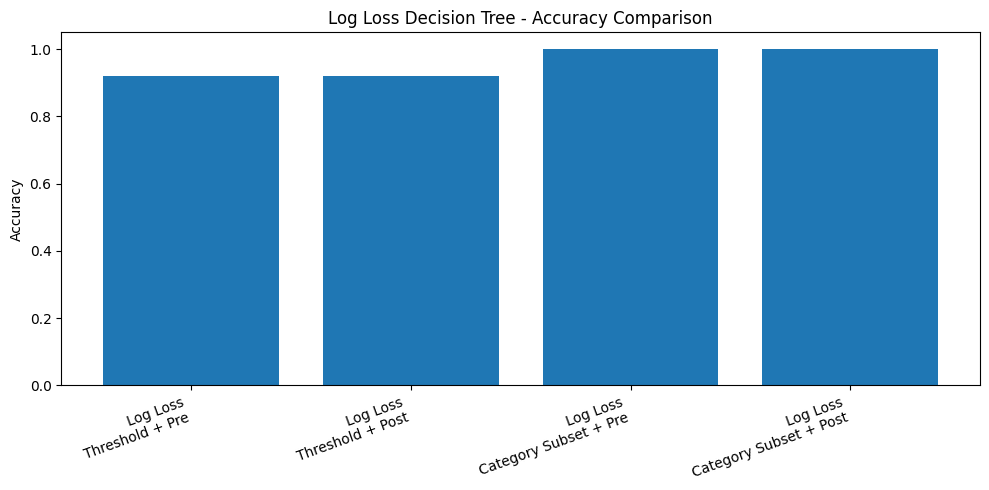

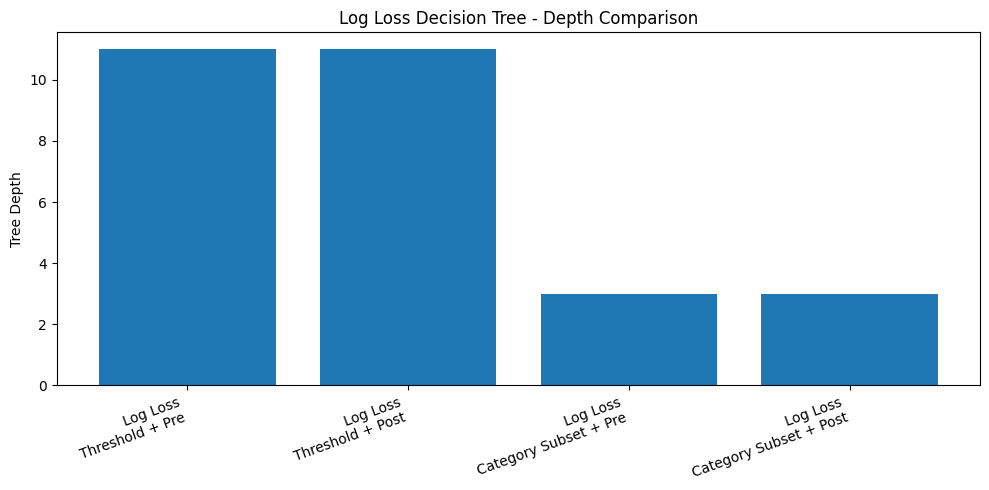

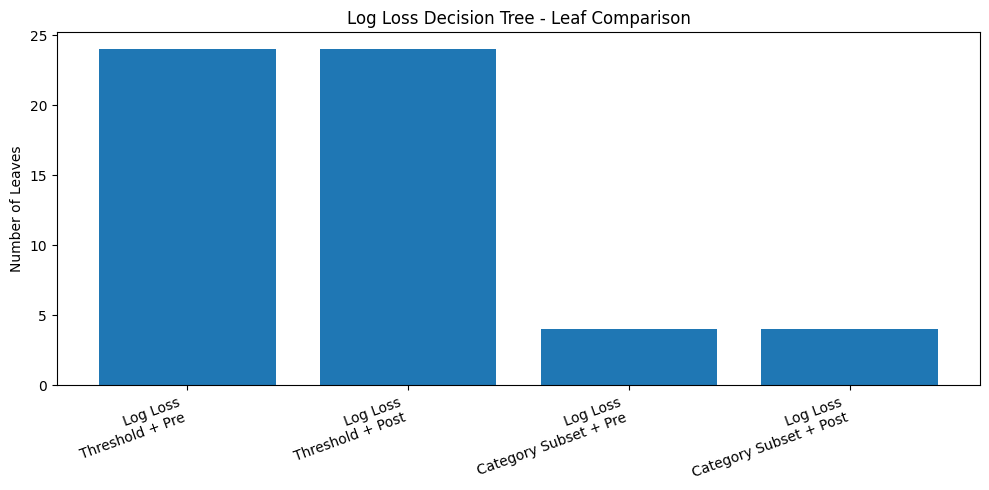


        LOG LOSS DECISION TREE RESULTS

1. Log Loss + Threshold + Pre-Pruning
--------------------------------------------------
Accuracy : 0.92
Depth    : 11
Leaves   : 24

2. Log Loss + Threshold + Post-Pruning
--------------------------------------------------
Accuracy : 0.92
Depth    : 11
Leaves   : 24

3. Log Loss + Category_Subset + Pre-Pruning
--------------------------------------------------
Accuracy : 1.00
Depth    : 3
Leaves   : 4

4. Log Loss + Category_Subset + Post-Pruning
--------------------------------------------------
Accuracy : 1.00
Depth    : 3
Leaves   : 4


                    MODEL COMPARISON


,Model,Accuracy,Depth,Leaves
0,Log Loss + Threshold + Pre,0.92,11,24
1,Log Loss + Threshold + Post,0.92,11,24
2,Log Loss + Category_Subset + Pre,1.00,3,4
3,Log Loss + Category_Subset + Post,1.00,3,4


In [ ]:
# log_loss

#=============================================
#             IMPORTS
#=============================================

import numpy as np

import pandas as pd

from itertools import combinations

import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split


#=============================================
#             Decision Tree Node
#=============================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        threshold=None,
        category_subset=None,
        left=None,
        right=None,
        value=None,
        class_counts=None
    ):

        self.feature_index = feature_index
        self.threshold = threshold
        self.category_subset = category_subset

        self.left = left
        self.right = right

        self.value = value
        self.class_counts = class_counts

    def is_leaf(self):

        return (
            self.left is None
            and
            self.right is None
        )


#=============================================
#       Log Loss Decision Tree Classifier
#=============================================

class DecisionTreeClassifier:

    def __init__(
        self,
        criterion="log_loss",
        split_strategy="Threshold",
        pruning="Pre",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0,
        random_state=None
    ):

        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes
        self.min_impurity_decrease = min_impurity_decrease

        self.ccp_alpha = ccp_alpha
        self.random_state = random_state

        self.root = None
        self.n_classes_ = None
        self.n_features_in_ = None
        self.classes_ = None

        self._rng = np.random.RandomState(
            random_state
        )

        self._leaf_count = 0

    #=========================================================
    # LOG LOSS
    #=========================================================

    def _log_loss(self, y):

        if len(y) == 0:
            return 0.0

        counts = np.bincount(
            y,
            minlength=self.n_classes_
        )

        probabilities = counts / len(y)

        probabilities = probabilities[
            probabilities > 0
        ]

        return -np.sum(
            probabilities *
            np.log(probabilities)
        )

    #=========================================================
    # FIND THRESHOLDS
    #=========================================================

    def _get_thresholds(self, X_column):

        values = np.unique(X_column)

        if len(values) <= 1:
            return []

        thresholds = (
            values[:-1] +
            values[1:]
        ) / 2.0

        return thresholds

    #=========================================================
    # CATEGORY SUBSETS
    #=========================================================

    def _get_category_subsets(self, X_column):

        categories = np.unique(X_column)

        if len(categories) <= 1:
            return []

        subsets = []

        n_categories = len(categories)

        for r in range(
            1,
            n_categories // 2 + 1
        ):

            for combination in combinations(
                categories,
                r
            ):

                subset = set(
                    combination
                )

                if r == n_categories - r:

                    first_category = categories[0]

                    if first_category not in subset:
                        continue

                subsets.append(
                    subset
                )

        return subsets

    #=========================================================
    # SPLIT DATA
    #=========================================================

    def _split(
        self,
        X,
        y,
        feature_index,
        threshold=None,
        category_subset=None
    ):

        column = X[:, feature_index]

        if self.split_strategy == "Threshold":

            left_mask = (
                column <= threshold
            )

            right_mask = (
                column > threshold
            )

        elif self.split_strategy == "Category_Subset":

            left_mask = np.array([
                value in category_subset
                for value in column
            ])

            right_mask = ~left_mask

        else:

            raise ValueError(
                "split_strategy must be "
                "'Threshold' or "
                "'Category_Subset'"
            )

        return (
            X[left_mask],
            X[right_mask],
            y[left_mask],
            y[right_mask]
        )

    #=========================================================
    # IMPURITY AFTER SPLIT
    #=========================================================

    def _split_impurity(
        self,
        y_left,
        y_right
    ):

        n = (
            len(y_left) +
            len(y_right)
        )

        if n == 0:
            return 0.0

        left_weight = (
            len(y_left) / n
        )

        right_weight = (
            len(y_right) / n
        )

        return (
            left_weight *
            self._log_loss(y_left)
            +
            right_weight *
            self._log_loss(y_right)
        )

    #=========================================================
    # IMPURITY DECREASE
    #=========================================================

    def _impurity_decrease(
        self,
        parent_y,
        left_y,
        right_y
    ):

        parent_impurity = (
            self._log_loss(parent_y)
        )

        child_impurity = (
            self._split_impurity(
                left_y,
                right_y
            )
        )

        return (
            parent_impurity -
            child_impurity
        )

    #=========================================================
    # SELECT FEATURES
    #=========================================================

    def _select_features(self):

        n_features = (
            self.n_features_in_
        )

        if self.max_features is None:

            return np.arange(
                n_features
            )

        if isinstance(
            self.max_features,
            int
        ):

            n_selected = min(
                self.max_features,
                n_features
            )

        elif isinstance(
            self.max_features,
            float
        ):

            n_selected = max(
                1,
                int(
                    self.max_features *
                    n_features
                )
            )

        elif self.max_features == "sqrt":

            n_selected = max(
                1,
                int(
                    np.sqrt(
                        n_features
                    )
                )
            )

        elif self.max_features == "log2":

            n_selected = max(
                1,
                int(
                    np.log2(
                        n_features
                    )
                )
            )

        else:

            raise ValueError(
                "Invalid max_features"
            )

        return self._rng.choice(
            n_features,
            size=n_selected,
            replace=False
        )

    #=========================================================
    # BEST THRESHOLD SPLIT
    #=========================================================

    def _best_threshold_split(
        self,
        X,
        y,
        feature_index
    ):

        best_impurity = np.inf

        best_threshold = None

        best_left = None
        best_right = None

        best_left_y = None
        best_right_y = None

        thresholds = (
            self._get_thresholds(
                X[:, feature_index]
            )
        )

        for threshold in thresholds:

            (
                X_left,
                X_right,
                y_left,
                y_right
            ) = self._split(
                X,
                y,
                feature_index,
                threshold=threshold
            )

            if (
                len(y_left)
                <
                self.min_samples_leaf
                or
                len(y_right)
                <
                self.min_samples_leaf
            ):

                continue

            impurity = (
                self._split_impurity(
                    y_left,
                    y_right
                )
            )

            if impurity < best_impurity:

                best_impurity = impurity

                best_threshold = threshold

                best_left = X_left
                best_right = X_right

                best_left_y = y_left
                best_right_y = y_right

        if best_threshold is None:

            return (
                np.inf,
                None,
                None,
                None,
                None,
                None
            )

        return (
            best_impurity,
            best_threshold,
            best_left,
            best_right,
            best_left_y,
            best_right_y
        )

    #=========================================================
    # BEST CATEGORY SPLIT
    #=========================================================

    def _best_category_split(
        self,
        X,
        y,
        feature_index
    ):

        best_impurity = np.inf

        best_subset = None

        best_left = None
        best_right = None

        best_left_y = None
        best_right_y = None

        subsets = (
            self._get_category_subsets(
                X[:, feature_index]
            )
        )

        for subset in subsets:

            (
                X_left,
                X_right,
                y_left,
                y_right
            ) = self._split(
                X,
                y,
                feature_index,
                category_subset=subset
            )

            if (
                len(y_left)
                <
                self.min_samples_leaf
                or
                len(y_right)
                <
                self.min_samples_leaf
            ):

                continue

            impurity = (
                self._split_impurity(
                    y_left,
                    y_right
                )
            )

            if impurity < best_impurity:

                best_impurity = impurity

                best_subset = subset

                best_left = X_left
                best_right = X_right

                best_left_y = y_left
                best_right_y = y_right

        if best_subset is None:

            return (
                np.inf,
                None,
                None,
                None,
                None,
                None
            )

        return (
            best_impurity,
            best_subset,
            best_left,
            best_right,
            best_left_y,
            best_right_y
        )

    #=========================================================
    # FIND BEST SPLIT
    #=========================================================

    def _best_split(
        self,
        X,
        y
    ):

        best_impurity = np.inf

        best_feature = None
        best_threshold = None
        best_subset = None

        best_left = None
        best_right = None

        best_left_y = None
        best_right_y = None

        features = (
            self._select_features()
        )

        for feature_index in features:

            if (
                self.split_strategy
                ==
                "Threshold"
            ):

                (
                    impurity,
                    threshold,
                    X_left,
                    X_right,
                    y_left,
                    y_right
                ) = self._best_threshold_split(
                    X,
                    y,
                    feature_index
                )

                if impurity < best_impurity:

                    best_impurity = impurity

                    best_feature = (
                        feature_index
                    )

                    best_threshold = (
                        threshold
                    )

                    best_left = X_left
                    best_right = X_right

                    best_left_y = y_left
                    best_right_y = y_right

            else:

                (
                    impurity,
                    subset,
                    X_left,
                    X_right,
                    y_left,
                    y_right
                ) = self._best_category_split(
                    X,
                    y,
                    feature_index
                )

                if impurity < best_impurity:

                    best_impurity = impurity

                    best_feature = (
                        feature_index
                    )

                    best_subset = subset

                    best_left = X_left
                    best_right = X_right

                    best_left_y = y_left
                    best_right_y = y_right

        if best_feature is None:

            return None

        return {
            "feature": best_feature,
            "threshold": best_threshold,
            "subset": best_subset,
            "impurity": best_impurity,
            "left": best_left,
            "right": best_right,
            "left_y": best_left_y,
            "right_y": best_right_y
        }

    #=========================================================
    # MAJORITY CLASS
    #=========================================================

    def _leaf_value(self, y):

        counts = np.bincount(
            y,
            minlength=self.n_classes_
        )

        return np.argmax(
            counts
        )

    #=========================================================
    # BUILD TREE
    #=========================================================

    def _build_tree(
        self,
        X,
        y,
        depth=0
    ):

        self._leaf_count += 1

        value = (
            self._leaf_value(y)
        )

        # Pure node
        if len(
            np.unique(y)
        ) == 1:

            return TreeNode(
                value=value,
                class_counts=np.bincount(
                    y,
                    minlength=self.n_classes_
                )
            )

        # Pre-pruning
        if self.pruning == "Pre":

            if (
                self.max_depth is not None
                and
                depth >= self.max_depth
            ):

                return TreeNode(
                    value=value,
                    class_counts=np.bincount(
                        y,
                        minlength=self.n_classes_
                    )
                )

            if (
                len(y)
                <
                self.min_samples_split
            ):

                return TreeNode(
                    value=value,
                    class_counts=np.bincount(
                        y,
                        minlength=self.n_classes_
                    )
                )

            if (
                self.max_leaf_nodes
                is not None
            ):

                if (
                    self._leaf_count
                    >=
                    self.max_leaf_nodes
                ):

                    return TreeNode(
                        value=value,
                        class_counts=np.bincount(
                            y,
                            minlength=self.n_classes_
                        )
                    )

        # Find best split
        split = (
            self._best_split(
                X,
                y
            )
        )

        if split is None:

            return TreeNode(
                value=value,
                class_counts=np.bincount(
                    y,
                    minlength=self.n_classes_
                )
            )

        decrease = (
            self._impurity_decrease(
                y,
                split["left_y"],
                split["right_y"]
            )
        )

        if (
            decrease
            <
            self.min_impurity_decrease
        ):

            return TreeNode(
                value=value,
                class_counts=np.bincount(
                    y,
                    minlength=self.n_classes_
                )
            )

        # Create children

        left = self._build_tree(
            split["left"],
            split["left_y"],
            depth + 1
        )

        right = self._build_tree(
            split["right"],
            split["right_y"],
            depth + 1
        )

        return TreeNode(
            feature_index=split["feature"],
            threshold=split["threshold"],
            category_subset=split["subset"],
            left=left,
            right=right,
            value=value,
            class_counts=np.bincount(
                y,
                minlength=self.n_classes_
            )
        )

    #=========================================================
    # COST COMPLEXITY PRUNING
    #=========================================================

    def _subtree_error(
        self,
        node
    ):

        if node.is_leaf():

            counts = (
                node.class_counts
            )

            return (
                np.sum(counts)
                -
                np.max(counts)
            )

        return (
            self._subtree_error(
                node.left
            )
            +
            self._subtree_error(
                node.right
            )
        )

    def _count_leaves(
        self,
        node
    ):

        if node.is_leaf():
            return 1

        return (
            self._count_leaves(
                node.left
            )
            +
            self._count_leaves(
                node.right
            )
        )

    def _prune(
        self,
        node
    ):

        if node.is_leaf():
            return

        self._prune(
            node.left
        )

        self._prune(
            node.right
        )

        subtree_error = (
            self._subtree_error(
                node
            )
        )

        n_leaves = (
            self._count_leaves(
                node
            )
        )

        leaf_error = (
            np.sum(
                node.class_counts
            )
            -
            np.max(
                node.class_counts
            )
        )

        if n_leaves > 1:

            alpha = (
                leaf_error -
                subtree_error
            ) / (
                n_leaves - 1
            )

            if (
                alpha
                <=
                self.ccp_alpha
            ):

                node.left = None
                node.right = None

                node.feature_index = None
                node.threshold = None
                node.category_subset = None

    #=========================================================
    # FIT
    #=========================================================

    def fit(
        self,
        X,
        y
    ):

        X = np.asarray(X)
        y = np.asarray(y)

        self.n_features_in_ = (
            X.shape[1]
        )

        self.classes_ = (
            np.unique(y)
        )

        class_mapping = {
            label: i
            for i, label
            in enumerate(
                self.classes_
            )
        }

        y_encoded = np.array([
            class_mapping[label]
            for label in y
        ])

        self.n_classes_ = (
            len(self.classes_)
        )

        self._leaf_count = 0

        self.root = (
            self._build_tree(
                X,
                y_encoded
            )
        )

        # Post-pruning
        if self.pruning == "Post":

            self._prune(
                self.root
            )

        return self

    #=========================================================
    # PREDICT ONE
    #=========================================================

    def _predict_one(
        self,
        x,
        node
    ):

        if node.is_leaf():

            return node.value

        if (
            self.split_strategy
            ==
            "Threshold"
        ):

            if (
                x[node.feature_index]
                <=
                node.threshold
            ):

                return self._predict_one(
                    x,
                    node.left
                )

            return self._predict_one(
                x,
                node.right
            )

        else:

            if (
                x[node.feature_index]
                in
                node.category_subset
            ):

                return self._predict_one(
                    x,
                    node.left
                )

            return self._predict_one(
                x,
                node.right
            )

    #=========================================================
    # PREDICT
    #=========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(X)

        predictions = [
            self._predict_one(
                x,
                self.root
            )
            for x in X
        ]

        return self.classes_[
            predictions
        ]

    #=========================================================
    # PREDICT PROBA ONE
    #=========================================================

    def _predict_proba_one(
        self,
        x,
        node
    ):

        if node.is_leaf():

            counts = (
                node.class_counts
            )

            total = np.sum(
                counts
            )

            if total == 0:

                return np.zeros(
                    self.n_classes_
                )

            return (
                counts / total
            )

        if (
            self.split_strategy
            ==
            "Threshold"
        ):

            if (
                x[node.feature_index]
                <=
                node.threshold
            ):

                return self._predict_proba_one(
                    x,
                    node.left
                )

            return self._predict_proba_one(
                x,
                node.right
            )

        else:

            if (
                x[node.feature_index]
                in
                node.category_subset
            ):

                return self._predict_proba_one(
                    x,
                    node.left
                )

            return self._predict_proba_one(
                x,
                node.right
            )

    #=========================================================
    # PREDICT PROBA
    #=========================================================

    def predict_proba(
        self,
        X
    ):

        X = np.asarray(X)

        return np.array([
            self._predict_proba_one(
                x,
                self.root
            )
            for x in X
        ])

    #=========================================================
    # SCORE
    #=========================================================

    def score(
        self,
        X,
        y
    ):

        predictions = (
            self.predict(X)
        )

        return np.mean(
            predictions == y
        )

    #=========================================================
    # TREE DEPTH
    #=========================================================

    def _tree_depth(
        self,
        node
    ):

        if node.is_leaf():

            return 0

        return (
            1 +
            max(
                self._tree_depth(
                    node.left
                ),
                self._tree_depth(
                    node.right
                )
            )
        )

    @property
    def depth(self):

        if self.root is None:

            return 0

        return self._tree_depth(
            self.root
        )

    #=========================================================
    # NUMBER OF LEAVES
    #=========================================================

    @property
    def n_leaves(self):

        if self.root is None:

            return 0

        return self._count_leaves(
            self.root
        )


#=============================================
#                  Numerical Dataset
#=============================================

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


#=============================================
#       log_loss + Threshold + Pre
#=============================================

model_log_threshold_pre = DecisionTreeClassifier(
    criterion="log_loss",
    split_strategy="Threshold",
    pruning="Pre",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    random_state=None
)

model_log_threshold_pre.fit(
    X_train,
    y_train
)


#=============================================
#       log_loss + Threshold + Post
#=============================================

model_log_threshold_post = DecisionTreeClassifier(
    criterion="log_loss",
    split_strategy="Threshold",
    pruning="Post",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.0,
    random_state=None
)

model_log_threshold_post.fit(
    X_train,
    y_train
)


#=============================================
#           Categorical Dataset
#=============================================

X_cat = np.array([
    ["Red", "Small"],
    ["Red", "Medium"],
    ["Red", "Large"],
    ["Blue", "Small"],
    ["Blue", "Medium"],
    ["Blue", "Large"],
    ["Green", "Small"],
    ["Green", "Medium"],
    ["Green", "Large"],
    ["Yellow", "Small"],
    ["Yellow", "Medium"],
    ["Yellow", "Large"],

    ["Red", "Small"],
    ["Red", "Large"],
    ["Blue", "Small"],
    ["Blue", "Large"],
    ["Green", "Medium"],
    ["Green", "Large"],
    ["Yellow", "Medium"],
    ["Yellow", "Large"]
])

y_cat = np.array([
    0,
    0,
    1,
    0,
    1,
    1,
    0,
    1,
    1,
    0,
    1,
    1,

    0,
    1,
    0,
    1,
    1,
    1,
    1,
    1
])

X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_cat,
    y_cat,
    test_size=0.25,
    random_state=42,
    stratify=y_cat
)


#=============================================
#       log_loss + Category_Subset + Pre
#=============================================

model_log_category_pre = DecisionTreeClassifier(
    criterion="log_loss",
    split_strategy="Category_Subset",
    pruning="Pre",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    random_state=None
)

model_log_category_pre.fit(
    X_cat_train,
    y_cat_train
)


#=============================================
#       log_loss + Category_Subset + Post
#=============================================

model_log_category_post = DecisionTreeClassifier(
    criterion="log_loss",
    split_strategy="Category_Subset",
    pruning="Post",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.0,
    random_state=None
)

model_log_category_post.fit(
    X_cat_train,
    y_cat_train
)


#=============================================
#       Comparison of Four Variants
#=============================================

models = [
    model_log_threshold_pre,
    model_log_threshold_post,
    model_log_category_pre,
    model_log_category_post
]

names = [
    "Log Loss\nThreshold + Pre",
    "Log Loss\nThreshold + Post",
    "Log Loss\nCategory Subset + Pre",
    "Log Loss\nCategory Subset + Post"
]

accuracies = [
    model_log_threshold_pre.score(
        X_test,
        y_test
    ),

    model_log_threshold_post.score(
        X_test,
        y_test
    ),

    model_log_category_pre.score(
        X_cat_test,
        y_cat_test
    ),

    model_log_category_post.score(
        X_cat_test,
        y_cat_test
    )
]

depths = [
    model_log_threshold_pre.depth,
    model_log_threshold_post.depth,
    model_log_category_pre.depth,
    model_log_category_post.depth
]

leaves = [
    model_log_threshold_pre.n_leaves,
    model_log_threshold_post.n_leaves,
    model_log_category_pre.n_leaves,
    model_log_category_post.n_leaves
]


#=============================================
#       Accuracy Comparison Plot
#=============================================

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    names,
    accuracies
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Log Loss Decision Tree - Accuracy Comparison"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.show()


#=============================================
#       Tree Depth Comparison
#=============================================

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    names,
    depths
)

plt.ylabel(
    "Tree Depth"
)

plt.title(
    "Log Loss Decision Tree - Depth Comparison"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.show()


#=============================================
#       Number of Leaves Comparison
#=============================================

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    names,
    leaves
)

plt.ylabel(
    "Number of Leaves"
)

plt.title(
    "Log Loss Decision Tree - Leaf Comparison"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.show()


#=============================================
#       Readable Results
#=============================================

print("\n" + "=" * 60)
print("        LOG LOSS DECISION TREE RESULTS")
print("=" * 60)

print("\n1. Log Loss + Threshold + Pre-Pruning")
print("-" * 50)
print(f"Accuracy : {model_log_threshold_pre.score(X_test, y_test):.2f}")
print(f"Depth    : {model_log_threshold_pre.depth}")
print(f"Leaves   : {model_log_threshold_pre.n_leaves}")

print("\n2. Log Loss + Threshold + Post-Pruning")
print("-" * 50)
print(f"Accuracy : {model_log_threshold_post.score(X_test, y_test):.2f}")
print(f"Depth    : {model_log_threshold_post.depth}")
print(f"Leaves   : {model_log_threshold_post.n_leaves}")

print("\n3. Log Loss + Category_Subset + Pre-Pruning")
print("-" * 50)
print(f"Accuracy : {model_log_category_pre.score(X_cat_test, y_cat_test):.2f}")
print(f"Depth    : {model_log_category_pre.depth}")
print(f"Leaves   : {model_log_category_pre.n_leaves}")

print("\n4. Log Loss + Category_Subset + Post-Pruning")
print("-" * 50)
print(f"Accuracy : {model_log_category_post.score(X_cat_test, y_cat_test):.2f}")
print(f"Depth    : {model_log_category_post.depth}")
print(f"Leaves   : {model_log_category_post.n_leaves}")

print("\n" + "=" * 60)

#=============================================
#       Comparison Table
#=============================================

comparison = pd.DataFrame({
    "Model": [
        "Log Loss + Threshold + Pre",
        "Log Loss + Threshold + Post",
        "Log Loss + Category_Subset + Pre",
        "Log Loss + Category_Subset + Post"
    ],

    "Accuracy": accuracies,
    "Depth": depths,
    "Leaves": leaves
})

comparison["Accuracy"] = comparison["Accuracy"].round(4)

print("\n" + "=" * 75)
print("                    MODEL COMPARISON")
print("=" * 75)

display(comparison)

print("=" * 75)


                  DECISION TREE RESULTS

Misclassification - Threshold - Pre
-------------------------------------------------------
Accuracy : 0.9000
Depth    : 1
Leaves   : 2

Misclassification - Threshold - Post
-------------------------------------------------------
Accuracy : 0.9000
Depth    : 1
Leaves   : 2

Misclassification - Category_Subset - Pre
-------------------------------------------------------
Accuracy : 0.9000
Depth    : 1
Leaves   : 2

Misclassification - Category_Subset - Post
-------------------------------------------------------
Accuracy : 0.9000
Depth    : 1
Leaves   : 2



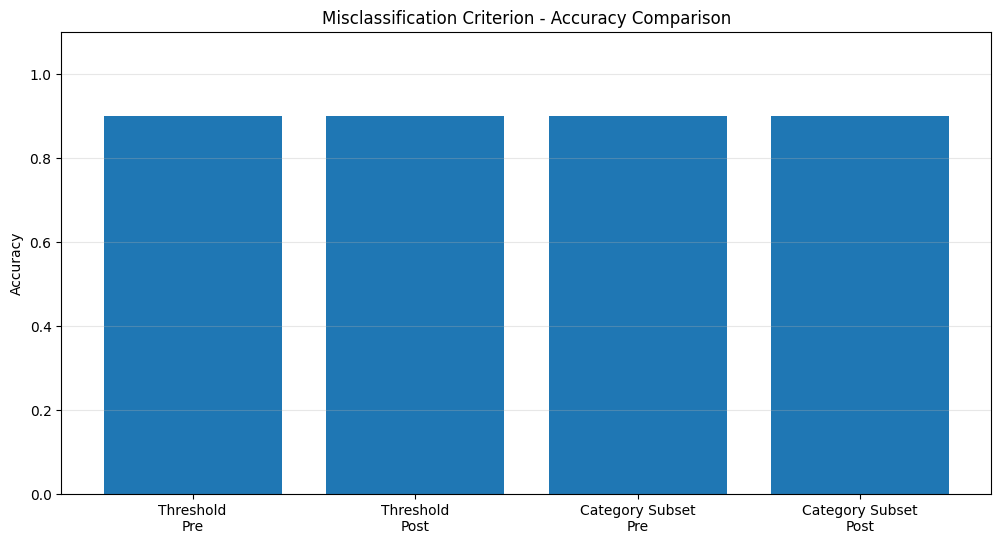

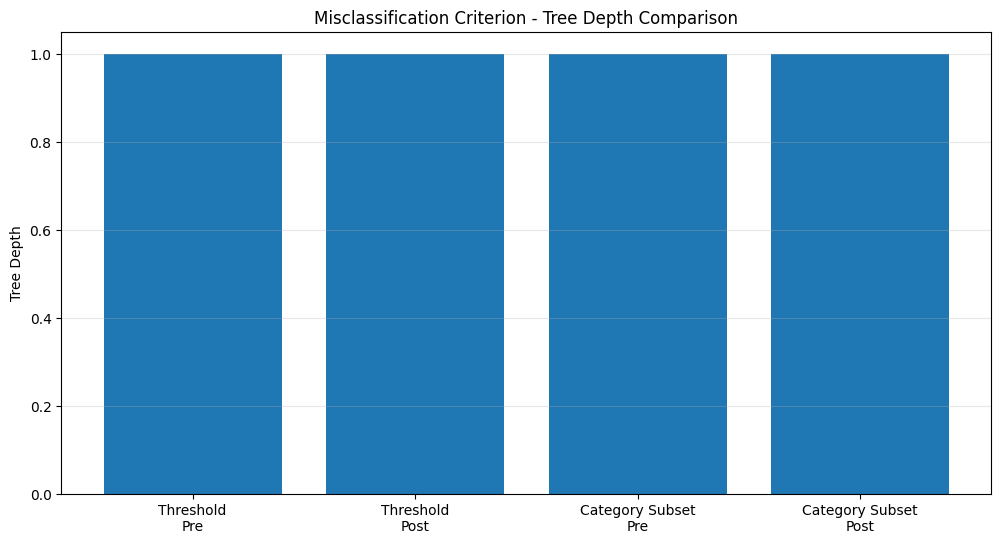

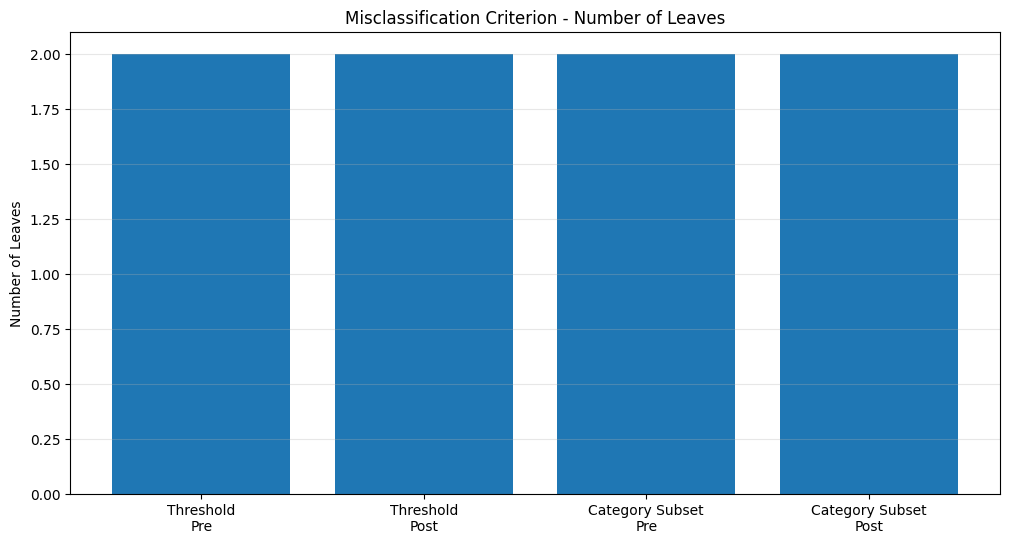

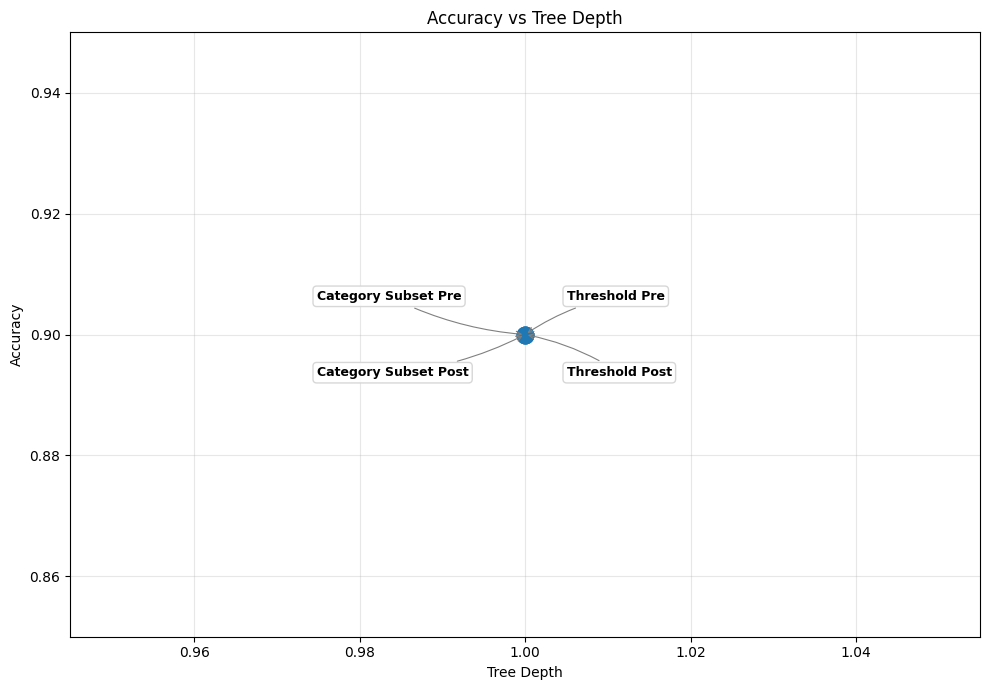

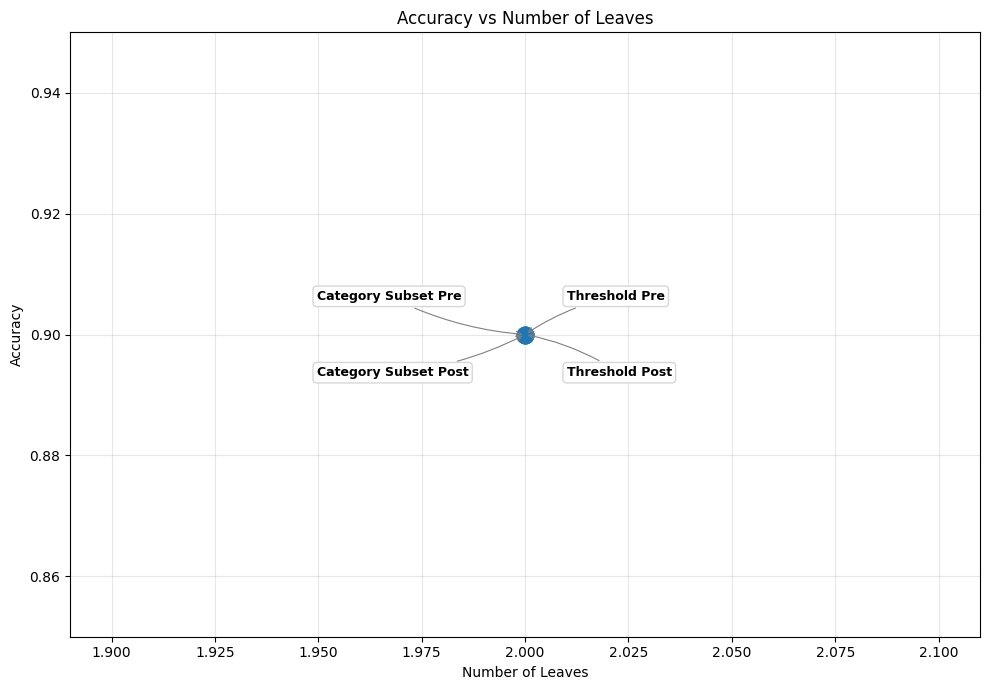

In [ ]:
# ============================================================
# DECISION TREE CLASSIFIER FROM SCRATCH
# Criterion:
#     misclassification
#
# Split strategies:
#     Threshold
#     Category_Subset
#
# Pruning:
#     Pre
#     Post
#
# No sklearn is used for the implementation.
# Only NumPy and Matplotlib are used.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        split_value=None,
        category_subset=None,
        left=None,
        right=None,
        prediction=None,
        probabilities=None,
        is_leaf=False
    ):

        self.feature_index = feature_index
        self.split_value = split_value
        self.category_subset = category_subset

        self.left = left
        self.right = right

        self.prediction = prediction
        self.probabilities = probabilities

        self.is_leaf = is_leaf


# ============================================================
# 2. DECISION TREE CLASSIFIER
# ============================================================

class DecisionTreeClassifier:

    def __init__(
        self,
        criterion="misclassification",
        split_strategy="Threshold",
        pruning="Pre",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0,
        random_state=None
    ):

        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes
        self.min_impurity_decrease = min_impurity_decrease

        self.ccp_alpha = ccp_alpha
        self.random_state = random_state

        self.rng = np.random.default_rng(random_state)

        self.root_ = None

        self.n_classes_ = None
        self.classes_ = None
        self.n_features_in_ = None

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0


    # ========================================================
    # 3. FIT
    # ========================================================

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim != 2:
            raise ValueError(
                "X must be a 2-dimensional array."
            )

        if y.ndim != 1:
            y = y.ravel()

        if X.shape[0] != y.shape[0]:
            raise ValueError(
                f"X and y have inconsistent numbers of samples: "
                f"{X.shape[0]} and {y.shape[0]}"
            )

        if X.shape[0] == 0:
            raise ValueError(
                "X and y cannot be empty."
            )

        if self.criterion != "misclassification":
            raise ValueError(
                "This implementation supports "
                'criterion="misclassification".'
            )

        if self.split_strategy not in [
            "Threshold",
            "Category_Subset"
        ]:
            raise ValueError(
                'split_strategy must be "Threshold" '
                'or "Category_Subset".'
            )

        if self.pruning not in [
            "Pre",
            "Post"
        ]:
            raise ValueError(
                'pruning must be "Pre" or "Post".'
            )

        self.n_features_in_ = X.shape[1]

        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)

        self.class_to_index_ = {
            cls: i
            for i, cls in enumerate(self.classes_)
        }

        y_encoded = np.array([
            self.class_to_index_[value]
            for value in y
        ])

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0

        self.root_ = self._build_tree(
            X,
            y_encoded,
            depth=0
        )

        if self.pruning == "Post":

            self.root_ = self._post_prune(
                self.root_,
                X,
                y_encoded
            )

        self.n_leaves_ = self._count_leaves(
            self.root_
        )

        self.tree_depth_ = self._calculate_depth(
            self.root_
        )

        self.node_count_ = self._count_nodes(
            self.root_
        )

        return self


    # ========================================================
    # 4. MISCLASSIFICATION IMPURITY
    # ========================================================

    def _misclassification_impurity(self, y):

        if len(y) == 0:
            return 0.0

        counts = np.bincount(
            y,
            minlength=self.n_classes_
        )

        probabilities = counts / len(y)

        return 1.0 - np.max(probabilities)


    # ========================================================
    # 5. CLASS PROBABILITIES
    # ========================================================

    def _class_probabilities(self, y):

        probabilities = np.zeros(
            self.n_classes_
        )

        if len(y) == 0:
            return probabilities

        counts = np.bincount(
            y,
            minlength=self.n_classes_
        )

        probabilities = counts / len(y)

        return probabilities


    # ========================================================
    # 6. MAJORITY CLASS
    # ========================================================

    def _majority_class(self, y):

        counts = np.bincount(
            y,
            minlength=self.n_classes_
        )

        return np.argmax(counts)


    # ========================================================
    # 7. IMPURITY DECREASE
    # ========================================================

    def _impurity_decrease(
        self,
        parent_y,
        left_y,
        right_y
    ):

        parent_impurity = (
            self._misclassification_impurity(
                parent_y
            )
        )

        left_impurity = (
            self._misclassification_impurity(
                left_y
            )
        )

        right_impurity = (
            self._misclassification_impurity(
                right_y
            )
        )

        n = len(parent_y)

        left_weight = len(left_y) / n
        right_weight = len(right_y) / n

        weighted_child_impurity = (
            left_weight * left_impurity
            +
            right_weight * right_impurity
        )

        decrease = (
            parent_impurity
            -
            weighted_child_impurity
        )

        return decrease


    # ========================================================
    # 8. BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth
    ):

        self.node_count_ += 1

        prediction = self._majority_class(y)

        probabilities = self._class_probabilities(y)

        if self._should_stop(
            X,
            y,
            depth
        ):

            return TreeNode(
                prediction=prediction,
                probabilities=probabilities,
                is_leaf=True
            )

        best_split = self._find_best_split(
            X,
            y
        )

        if best_split is None:

            return TreeNode(
                prediction=prediction,
                probabilities=probabilities,
                is_leaf=True
            )

        feature_index = (
            best_split["feature_index"]
        )

        split_value = (
            best_split["split_value"]
        )

        category_subset = (
            best_split["category_subset"]
        )

        left_indices = (
            best_split["left_indices"]
        )

        right_indices = (
            best_split["right_indices"]
        )

        decrease = (
            best_split["impurity_decrease"]
        )

        if decrease < self.min_impurity_decrease:

            return TreeNode(
                prediction=prediction,
                probabilities=probabilities,
                is_leaf=True
            )

        X_left = X[left_indices]
        y_left = y[left_indices]

        X_right = X[right_indices]
        y_right = y[right_indices]

        left_child = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_child = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return TreeNode(
            feature_index=feature_index,
            split_value=split_value,
            category_subset=category_subset,
            left=left_child,
            right=right_child,
            prediction=prediction,
            probabilities=probabilities,
            is_leaf=False
        )


    # ========================================================
    # 9. STOPPING CONDITIONS / PRE-PRUNING
    # ========================================================

    def _should_stop(
        self,
        X,
        y,
        depth
    ):

        if len(np.unique(y)) == 1:
            return True

        if (
            self.max_depth is not None
            and depth >= self.max_depth
        ):
            return True

        if len(y) < self.min_samples_split:
            return True

        if len(y) < 2 * self.min_samples_leaf:
            return True

        return False


    # ========================================================
    # 10. FIND BEST SPLIT
    # ========================================================

    def _find_best_split(
        self,
        X,
        y
    ):

        best_split = None
        best_decrease = -np.inf

        feature_indices = np.arange(
            X.shape[1]
        )

        if self.max_features is not None:

            if isinstance(
                self.max_features,
                int
            ):

                n_features = min(
                    self.max_features,
                    X.shape[1]
                )

                feature_indices = self.rng.choice(
                    X.shape[1],
                    size=n_features,
                    replace=False
                )

        for feature_index in feature_indices:

            column = X[:, feature_index]

            if self.split_strategy == "Threshold":

                split = self._find_threshold_split(
                    column,
                    y,
                    feature_index
                )

            else:

                split = self._find_category_subset_split(
                    column,
                    y,
                    feature_index
                )

            if split is not None:

                decrease = split[
                    "impurity_decrease"
                ]

                if decrease > best_decrease:

                    best_decrease = decrease
                    best_split = split

        return best_split


    # ========================================================
    # 11. THRESHOLD SPLIT
    # ========================================================

    def _find_threshold_split(
        self,
        column,
        y,
        feature_index
    ):

        try:

            values = column.astype(float)

        except:

            return None

        unique_values = np.unique(
            values
        )

        if len(unique_values) < 2:
            return None

        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0

        best_split = None
        best_decrease = -np.inf

        for threshold in thresholds:

            left_indices = np.where(
                values <= threshold
            )[0]

            right_indices = np.where(
                values > threshold
            )[0]

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):
                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):
                continue

            left_y = y[left_indices]
            right_y = y[right_indices]

            decrease = self._impurity_decrease(
                y,
                left_y,
                right_y
            )

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        threshold,

                    "category_subset":
                        None,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 12. CATEGORY SUBSET SPLIT
    # ========================================================

    def _find_category_subset_split(
        self,
        column,
        y,
        feature_index
    ):

        categories = np.unique(
            column
        )

        if len(categories) < 2:
            return None

        if len(categories) == 2:

            subsets = [
                {categories[0]}
            ]

        else:

            subsets = []

            if len(categories) <= 10:

                from itertools import combinations

                first_category = categories[0]

                remaining = categories[1:]

                for r in range(
                    0,
                    len(remaining)
                ):

                    for combo in combinations(
                        remaining,
                        r
                    ):

                        subset = {
                            first_category,
                            *combo
                        }

                        if len(subset) < len(categories):

                            subsets.append(
                                subset
                            )

            else:

                category_scores = []

                for category in categories:

                    mask = (
                        column == category
                    )

                    category_y = y[mask]

                    probabilities = (
                        self._class_probabilities(
                            category_y
                        )
                    )

                    score = np.argmax(
                        probabilities
                    )

                    category_scores.append(
                        (
                            category,
                            score
                        )
                    )

                category_scores.sort(
                    key=lambda x: x[1]
                )

                ordered_categories = [
                    x[0]
                    for x in category_scores
                ]

                for i in range(
                    1,
                    len(ordered_categories)
                ):

                    subsets.append(
                        set(
                            ordered_categories[:i]
                        )
                    )

        best_split = None
        best_decrease = -np.inf

        for subset in subsets:

            left_mask = np.array([
                value in subset
                for value in column
            ])

            right_mask = ~left_mask

            left_indices = np.where(
                left_mask
            )[0]

            right_indices = np.where(
                right_mask
            )[0]

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):
                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):
                continue

            left_y = y[left_indices]
            right_y = y[right_indices]

            decrease = self._impurity_decrease(
                y,
                left_y,
                right_y
            )

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        None,

                    "category_subset":
                        subset,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 13. PREDICTION FOR ONE SAMPLE
    # ========================================================

    def _predict_one(self, x):

        node = self.root_

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            if node.category_subset is None:

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 14. PREDICT
    # ========================================================

    def predict(self, X):

        X = np.asarray(X)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        predictions = np.array([
            self._predict_one(x)
            for x in X
        ])

        return self.classes_[
            predictions
        ]


    # ========================================================
    # 15. PREDICT PROBA
    # ========================================================

    def _predict_proba_one(self, x):

        node = self.root_

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            if node.category_subset is None:

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.probabilities


    def predict_proba(self, X):

        X = np.asarray(X)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        return np.array([
            self._predict_proba_one(x)
            for x in X
        ])


    # ========================================================
    # 16. SCORE
    # ========================================================

    def score(self, X, y):

        predictions = self.predict(X)

        y = np.asarray(y)

        return np.mean(
            predictions == y
        )


    # ========================================================
    # 17. COUNT LEAVES
    # ========================================================

    def _count_leaves(self, node):

        if node is None:
            return 0

        if node.is_leaf:
            return 1

        return (
            self._count_leaves(node.left)
            +
            self._count_leaves(node.right)
        )


    # ========================================================
    # 18. COUNT NODES
    # ========================================================

    def _count_nodes(self, node):

        if node is None:
            return 0

        if node.is_leaf:
            return 1

        return (
            1
            +
            self._count_nodes(node.left)
            +
            self._count_nodes(node.right)
        )


    # ========================================================
    # 19. CALCULATE TREE DEPTH
    # ========================================================

    def _calculate_depth(self, node):

        if node is None:
            return 0

        if node.is_leaf:
            return 0

        return 1 + max(
            self._calculate_depth(node.left),
            self._calculate_depth(node.right)
        )


    # ========================================================
    # 20. GET DEPTH
    # ========================================================

    def get_depth(self):

        return self.tree_depth_


    # ========================================================
    # 21. GET NUMBER OF LEAVES
    # ========================================================

    def get_n_leaves(self):

        return self.n_leaves_


    # ========================================================
    # 22. POST-PRUNING
    # ========================================================

    def _post_prune(
        self,
        node,
        X,
        y
    ):

        if node is None:
            return node

        if node.is_leaf:
            return node

        if len(y) == 0:
            return node

        left_indices, right_indices = (
            self._split_indices_for_node(
                node,
                X
            )
        )

        X_left = X[left_indices]
        y_left = y[left_indices]

        X_right = X[right_indices]
        y_right = y[right_indices]

        node.left = self._post_prune(
            node.left,
            X_left,
            y_left
        )

        node.right = self._post_prune(
            node.right,
            X_right,
            y_right
        )

        subtree_predictions = np.array([
            self._predict_node(
                node,
                x
            )
            for x in X
        ])

        subtree_error = np.sum(
            subtree_predictions != y
        )

        leaf_prediction = self._majority_class(
            y
        )

        leaf_error = np.sum(
            y != leaf_prediction
        )

        subtree_leaves = self._count_leaves(
            node
        )

        subtree_cost = (
            subtree_error
            +
            self.ccp_alpha * subtree_leaves
        )

        leaf_cost = (
            leaf_error
            +
            self.ccp_alpha
        )

        if leaf_cost <= subtree_cost:

            probabilities = (
                self._class_probabilities(y)
            )

            node = TreeNode(
                prediction=leaf_prediction,
                probabilities=probabilities,
                is_leaf=True
            )

        return node


    # ========================================================
    # 23. SPLIT INDICES FOR EXISTING NODE
    # ========================================================

    def _split_indices_for_node(
        self,
        node,
        X
    ):

        values = X[
            :,
            node.feature_index
        ]

        if node.category_subset is None:

            try:
                values = values.astype(float)
            except:
                pass

            left_mask = (
                values
                <=
                node.split_value
            )

        else:

            left_mask = np.array([
                value in node.category_subset
                for value in values
            ])

        right_mask = ~left_mask

        return (
            np.where(left_mask)[0],
            np.where(right_mask)[0]
        )


    # ========================================================
    # 24. PREDICT FROM SPECIFIC NODE
    # ========================================================

    def _predict_node(
        self,
        node,
        x
    ):

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            if node.category_subset is None:

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 25. PRINT TREE
    # ========================================================

    def print_tree(
        self,
        node=None,
        depth=0
    ):

        if node is None:
            node = self.root_

        indentation = "    " * depth

        if node.is_leaf:

            print(
                indentation
                +
                f"Leaf: "
                f"class={self.classes_[node.prediction]}"
            )

            return

        if node.category_subset is None:

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"<= {node.split_value:.4f}"
            )

        else:

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"in {node.category_subset}"
            )

        self.print_tree(
            node.left,
            depth + 1
        )

        self.print_tree(
            node.right,
            depth + 1
        )


# ============================================================
# 26. CREATE SAMPLE DATA
# ============================================================

rng = np.random.default_rng(42)

X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [2, 2],
    [3, 1],
    [3, 2],
    [4, 1],
    [4, 2],
    [5, 1],
    [5, 2],
    [6, 1],
    [6, 2],
    [7, 1],
    [7, 2],
    [8, 1],
    [8, 2],
    [9, 1],
    [9, 2],
    [10, 1],
    [10, 2]
])

y = np.array([
    0, 0,
    0, 0,
    0, 0,
    0, 1,
    0, 1,
    1, 1,
    1, 1,
    1, 1,
    1, 1,
    1, 1
])


# ============================================================
# 27. FOUR REQUIRED CONFIGURATIONS
# ============================================================

models = {

    "Misclassification - Threshold - Pre":
        DecisionTreeClassifier(
            criterion="misclassification",
            split_strategy="Threshold",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),

    "Misclassification - Threshold - Post":
        DecisionTreeClassifier(
            criterion="misclassification",
            split_strategy="Threshold",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.0,
            random_state=42
        ),

    "Misclassification - Category_Subset - Pre":
        DecisionTreeClassifier(
            criterion="misclassification",
            split_strategy="Category_Subset",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),

    "Misclassification - Category_Subset - Post":
        DecisionTreeClassifier(
            criterion="misclassification",
            split_strategy="Category_Subset",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.0,
            random_state=42
        )
}


# ============================================================
# 28. TRAIN ALL FOUR MODELS
# ============================================================

results = {}

for name, model in models.items():

    model.fit(X, y)

    accuracy = model.score(
        X,
        y
    )

    depth = model.get_depth()

    leaves = model.get_n_leaves()

    results[name] = {
        "accuracy": accuracy,
        "depth": depth,
        "leaves": leaves
    }


# ============================================================
# 29. CLEAN COMPARISON OUTPUT
# ============================================================

print("\n" + "=" * 75)
print("                  DECISION TREE RESULTS")
print("=" * 75)

for name, result in results.items():

    print("\n" + name)
    print("-" * 55)

    print(
        f"Accuracy : {result['accuracy']:.4f}"
    )

    print(
        f"Depth    : {result['depth']}"
    )

    print(
        f"Leaves   : {result['leaves']}"
    )

print("\n" + "=" * 75)


# ============================================================
# 30. PREPARE PLOT DATA
# ============================================================

names = list(results.keys())

accuracies = [
    results[name]["accuracy"]
    for name in names
]

depths = [
    results[name]["depth"]
    for name in names
]

leaves = [
    results[name]["leaves"]
    for name in names
]


# ============================================================
# 31. ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(names)),
    accuracies
)

plt.xticks(
    range(len(names)),
    [
        "Threshold\nPre",
        "Threshold\nPost",
        "Category Subset\nPre",
        "Category Subset\nPost"
    ]
)

plt.ylabel("Accuracy")

plt.title(
    "Misclassification Criterion - Accuracy Comparison"
)

plt.ylim(
    0,
    1.1
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 32. TREE DEPTH COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(names)),
    depths
)

plt.xticks(
    range(len(names)),
    [
        "Threshold\nPre",
        "Threshold\nPost",
        "Category Subset\nPre",
        "Category Subset\nPost"
    ]
)

plt.ylabel("Tree Depth")

plt.title(
    "Misclassification Criterion - Tree Depth Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 33. NUMBER OF LEAVES COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(names)),
    leaves
)

plt.xticks(
    range(len(names)),
    [
        "Threshold\nPre",
        "Threshold\nPost",
        "Category Subset\nPre",
        "Category Subset\nPost"
    ]
)

plt.ylabel("Number of Leaves")

plt.title(
    "Misclassification Criterion - Number of Leaves"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# ============================================================
# 34. ACCURACY vs TREE COMPLEXITY (FIXED OVERLAP)
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    depths,
    accuracies,
    s=140,
    color="#1f77b4",
    zorder=3
)

labels = [
    "Threshold Pre",
    "Threshold Post",
    "Category Subset Pre",
    "Category Subset Post"
]

# Distinct directional offsets for each configuration
offsets_34 = [
    (30, 25),    # Top-Right
    (30, -30),   # Bottom-Right
    (-150, 25),  # Top-Left
    (-150, -30)  # Bottom-Left
]

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (depths[i], accuracies[i]),
        xytext=offsets_34[i],
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=0.1",
            color="gray",
            lw=0.8
        ),
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.9
        )
    )

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.ylim(0.85, 0.95)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 35. ACCURACY vs NUMBER OF LEAVES (FIXED OVERLAP)
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    leaves,
    accuracies,
    s=140,
    color="#1f77b4",
    zorder=3
)

offsets_35 = [
    (30, 25),    # Top-Right
    (30, -30),   # Bottom-Right
    (-150, 25),  # Top-Left
    (-150, -30)  # Bottom-Left
]

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (leaves[i], accuracies[i]),
        xytext=offsets_35[i],
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=0.1",
            color="gray",
            lw=0.8
        ),
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.9
        )
    )

plt.xlabel("Number of Leaves")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Leaves")
plt.ylim(0.85, 0.95)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


                  DECISION TREE RESULTS

Chi-Square - Threshold - Pre
-------------------------------------------------------
Accuracy : 1.0000
Depth    : 3
Leaves   : 4

Chi-Square - Threshold - Post
-------------------------------------------------------
Accuracy : 1.0000
Depth    : 3
Leaves   : 4

Chi-Square - Category_Subset - Pre
-------------------------------------------------------
Accuracy : 1.0000
Depth    : 3
Leaves   : 4

Chi-Square - Category_Subset - Post
-------------------------------------------------------
Accuracy : 1.0000
Depth    : 3
Leaves   : 4



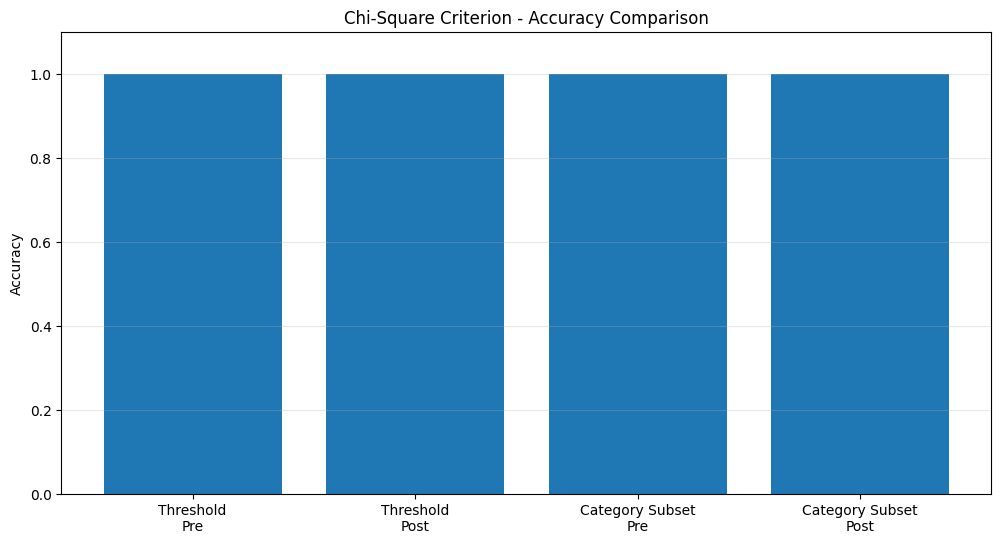

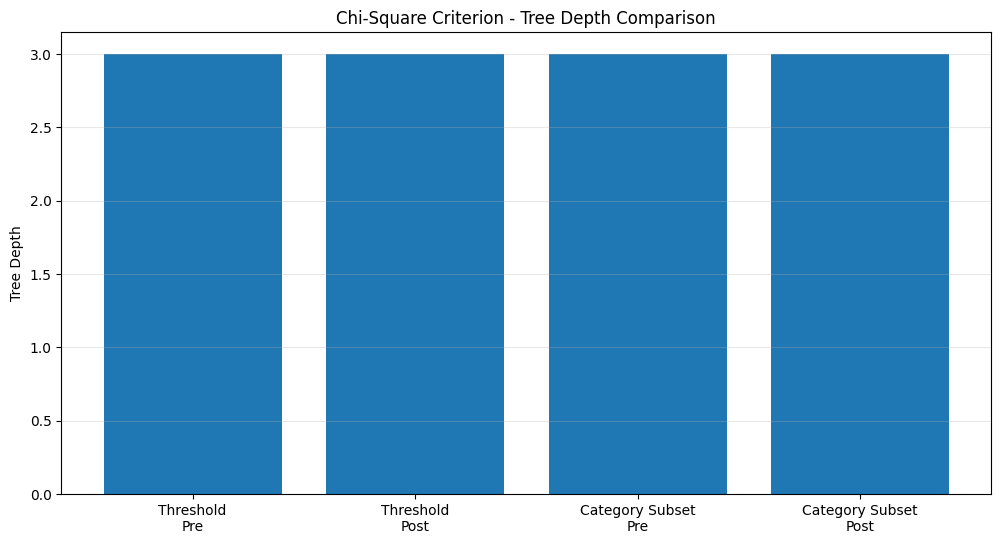

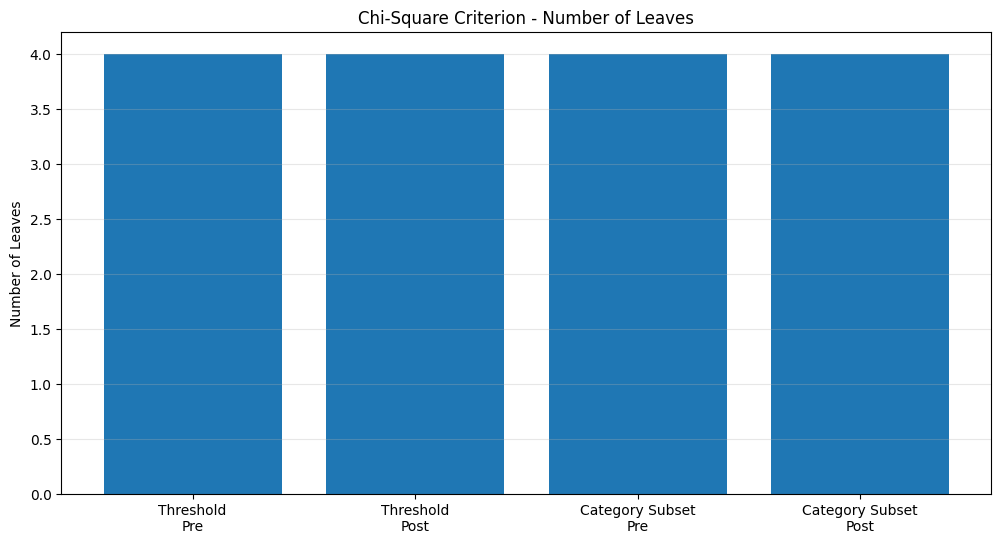

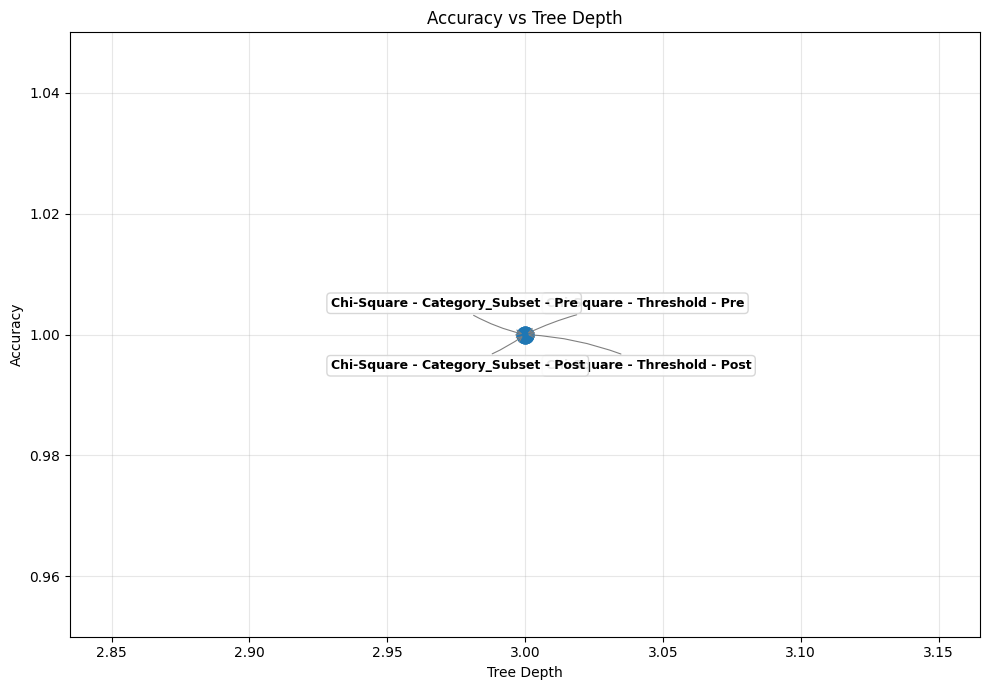

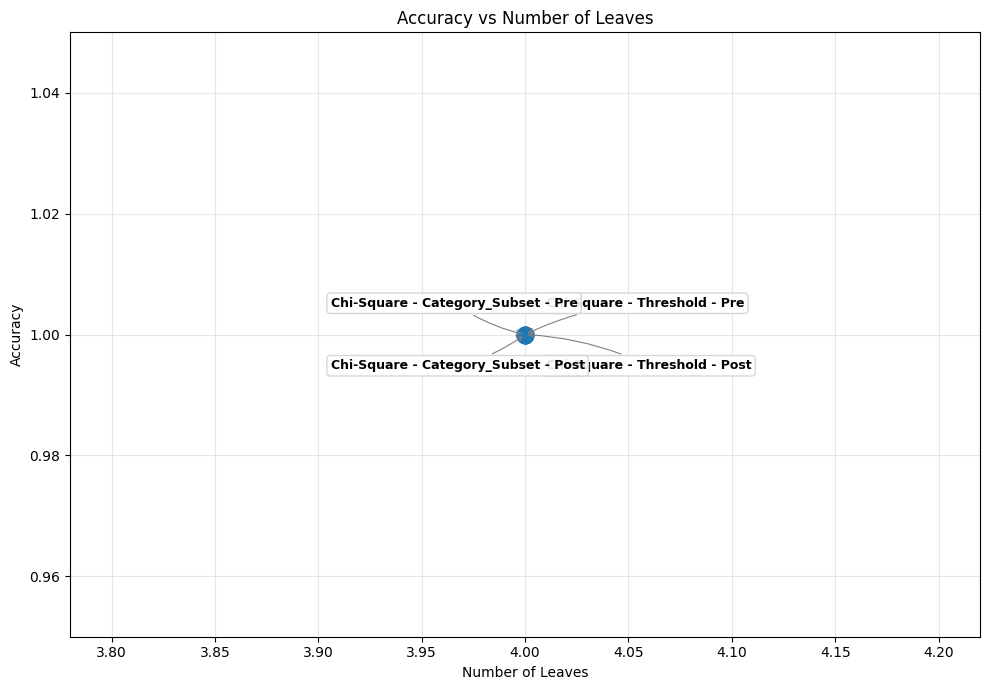

In [ ]:
# ============================================================
# DECISION TREE CLASSIFIER FROM SCRATCH
# Criterion:
#     chi_square
#
# Split strategies:
#     Threshold
#     Category_Subset
#
# Pruning:
#     Pre
#     Post
#
# No sklearn is used for the implementation.
# Only NumPy and Matplotlib are used.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        split_value=None,
        category_subset=None,
        left=None,
        right=None,
        prediction=None,
        probabilities=None,
        is_leaf=False
    ):

        self.feature_index = feature_index
        self.split_value = split_value
        self.category_subset = category_subset

        self.left = left
        self.right = right

        self.prediction = prediction
        self.probabilities = probabilities

        self.is_leaf = is_leaf


# ============================================================
# 2. DECISION TREE CLASSIFIER
# ============================================================

class DecisionTreeClassifier:

    def __init__(
        self,
        criterion="chi_square",
        split_strategy="Threshold",
        pruning="Pre",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0,
        random_state=None
    ):

        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes
        self.min_impurity_decrease = min_impurity_decrease

        self.ccp_alpha = ccp_alpha
        self.random_state = random_state

        self.rng = np.random.default_rng(random_state)

        self.root_ = None

        self.n_classes_ = None
        self.classes_ = None
        self.n_features_in_ = None

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0


    # ========================================================
    # 3. FIT
    # ========================================================

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim != 2:
            raise ValueError(
                "X must be a 2-dimensional array."
            )

        if y.ndim != 1:
            y = y.ravel()

        if X.shape[0] != y.shape[0]:
            raise ValueError(
                f"X and y have inconsistent numbers of samples: "
                f"{X.shape[0]} and {y.shape[0]}"
            )

        if X.shape[0] == 0:
            raise ValueError(
                "X and y cannot be empty."
            )

        if self.criterion != "chi_square":
            raise ValueError(
                "This implementation supports "
                'criterion="chi_square".'
            )

        if self.split_strategy not in [
            "Threshold",
            "Category_Subset"
        ]:
            raise ValueError(
                'split_strategy must be "Threshold" '
                'or "Category_Subset".'
            )

        if self.pruning not in [
            "Pre",
            "Post"
        ]:
            raise ValueError(
                'pruning must be "Pre" or "Post".'
            )

        self.n_features_in_ = X.shape[1]

        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)

        self.class_to_index_ = {
            cls: i
            for i, cls in enumerate(self.classes_)
        }

        y_encoded = np.array([
            self.class_to_index_[value]
            for value in y
        ])

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0

        self.root_ = self._build_tree(
            X,
            y_encoded,
            depth=0
        )

        if self.pruning == "Post":

            self.root_ = self._post_prune(
                self.root_,
                X,
                y_encoded
            )

        self.n_leaves_ = self._count_leaves(
            self.root_
        )

        self.tree_depth_ = self._calculate_depth(
            self.root_
        )

        self.node_count_ = self._count_nodes(
            self.root_
        )

        return self


    # ========================================================
    # 4. CHI-SQUARE IMPURITY
    # ========================================================

    def _chi_square_score(
        self,
        left_y,
        right_y
    ):

        if (
            len(left_y) == 0
            or
            len(right_y) == 0
        ):
            return 0.0

        observed = np.zeros(
            (2, self.n_classes_)
        )

        for class_index in range(
            self.n_classes_
        ):

            observed[0, class_index] = np.sum(
                left_y == class_index
            )

            observed[1, class_index] = np.sum(
                right_y == class_index
            )

        row_totals = observed.sum(
            axis=1,
            keepdims=True
        )

        column_totals = observed.sum(
            axis=0,
            keepdims=True
        )

        total = observed.sum()

        if total == 0:
            return 0.0

        expected = (
            row_totals
            *
            column_totals
            /
            total
        )

        chi_square = 0.0

        for i in range(
            observed.shape[0]
        ):

            for j in range(
                observed.shape[1]
            ):

                if expected[i, j] > 0:

                    chi_square += (
                        (
                            observed[i, j]
                            -
                            expected[i, j]
                        ) ** 2
                        /
                        expected[i, j]
                    )

        return chi_square


    # ========================================================
    # 5. CLASS PROBABILITIES
    # ========================================================

    def _class_probabilities(self, y):

        probabilities = np.zeros(
            self.n_classes_
        )

        if len(y) == 0:
            return probabilities

        counts = np.bincount(
            y,
            minlength=self.n_classes_
        )

        probabilities = counts / len(y)

        return probabilities


    # ========================================================
    # 6. MAJORITY CLASS
    # ========================================================

    def _majority_class(self, y):

        counts = np.bincount(
            y,
            minlength=self.n_classes_
        )

        return np.argmax(counts)


    # ========================================================
    # 7. CHI-SQUARE SPLIT SCORE
    # ========================================================

    def _impurity_decrease(
        self,
        parent_y,
        left_y,
        right_y
    ):

        return self._chi_square_score(
            left_y,
            right_y
        )


    # ========================================================
    # 8. BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth
    ):

        self.node_count_ += 1

        prediction = self._majority_class(y)

        probabilities = self._class_probabilities(y)

        if self._should_stop(
            X,
            y,
            depth
        ):

            return TreeNode(
                prediction=prediction,
                probabilities=probabilities,
                is_leaf=True
            )

        best_split = self._find_best_split(
            X,
            y
        )

        if best_split is None:

            return TreeNode(
                prediction=prediction,
                probabilities=probabilities,
                is_leaf=True
            )

        feature_index = (
            best_split["feature_index"]
        )

        split_value = (
            best_split["split_value"]
        )

        category_subset = (
            best_split["category_subset"]
        )

        left_indices = (
            best_split["left_indices"]
        )

        right_indices = (
            best_split["right_indices"]
        )

        decrease = (
            best_split["impurity_decrease"]
        )

        if decrease < self.min_impurity_decrease:

            return TreeNode(
                prediction=prediction,
                probabilities=probabilities,
                is_leaf=True
            )

        X_left = X[left_indices]
        y_left = y[left_indices]

        X_right = X[right_indices]
        y_right = y[right_indices]

        left_child = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_child = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return TreeNode(
            feature_index=feature_index,
            split_value=split_value,
            category_subset=category_subset,
            left=left_child,
            right=right_child,
            prediction=prediction,
            probabilities=probabilities,
            is_leaf=False
        )


    # ========================================================
    # 9. STOPPING CONDITIONS / PRE-PRUNING
    # ========================================================

    def _should_stop(
        self,
        X,
        y,
        depth
    ):

        if len(np.unique(y)) == 1:
            return True

        if (
            self.max_depth is not None
            and depth >= self.max_depth
        ):
            return True

        if len(y) < self.min_samples_split:
            return True

        if len(y) < 2 * self.min_samples_leaf:
            return True

        return False


    # ========================================================
    # 10. FIND BEST SPLIT
    # ========================================================

    def _find_best_split(
        self,
        X,
        y
    ):

        best_split = None
        best_decrease = -np.inf

        feature_indices = np.arange(
            X.shape[1]
        )

        if self.max_features is not None:

            if isinstance(
                self.max_features,
                int
            ):

                n_features = min(
                    self.max_features,
                    X.shape[1]
                )

                feature_indices = self.rng.choice(
                    X.shape[1],
                    size=n_features,
                    replace=False
                )

        for feature_index in feature_indices:

            column = X[:, feature_index]

            if self.split_strategy == "Threshold":

                split = self._find_threshold_split(
                    column,
                    y,
                    feature_index
                )

            else:

                split = self._find_category_subset_split(
                    column,
                    y,
                    feature_index
                )

            if split is not None:

                decrease = split[
                    "impurity_decrease"
                ]

                if decrease > best_decrease:

                    best_decrease = decrease
                    best_split = split

        return best_split


    # ========================================================
    # 11. THRESHOLD SPLIT
    # ========================================================

    def _find_threshold_split(
        self,
        column,
        y,
        feature_index
    ):

        try:

            values = column.astype(float)

        except:

            return None

        unique_values = np.unique(
            values
        )

        if len(unique_values) < 2:
            return None

        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0

        best_split = None
        best_decrease = -np.inf

        for threshold in thresholds:

            left_indices = np.where(
                values <= threshold
            )[0]

            right_indices = np.where(
                values > threshold
            )[0]

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):
                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):
                continue

            left_y = y[left_indices]
            right_y = y[right_indices]

            decrease = self._impurity_decrease(
                y,
                left_y,
                right_y
            )

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        threshold,

                    "category_subset":
                        None,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 12. CATEGORY SUBSET SPLIT (FIXED)
    # ========================================================

    def _find_category_subset_split(
        self,
        column,
        y,
        feature_index
    ):

        categories = np.unique(
            column
        )

        if len(categories) < 2:
            return None

        if len(categories) == 2:

            subsets = [
                {categories[0]}
            ]

        else:

            subsets = []

            if len(categories) <= 10:

                from itertools import combinations

                first_category = categories[0]
                remaining = categories[1:]

                for r in range(
                    0,
                    len(remaining)
                ):

                    for combo in combinations(
                        remaining,
                        r
                    ):

                        subset = {
                            first_category,
                            *combo
                        }

                        if len(subset) < len(categories):

                            subsets.append(
                                subset
                            )

            else:

                # Fix: continuous probability ranking to prevent ties/arbitrary ordering
                category_scores = []

                for category in categories:

                    mask = (
                        column == category
                    )

                    category_y = y[mask]

                    probabilities = (
                        self._class_probabilities(
                            category_y
                        )
                    )

                    score = probabilities[1] if self.n_classes_ > 1 else probabilities[0]

                    category_scores.append(
                        (
                            category,
                            score
                        )
                    )

                category_scores.sort(
                    key=lambda x: x[1]
                )

                ordered_categories = [
                    x[0]
                    for x in category_scores
                ]

                for i in range(
                    1,
                    len(ordered_categories)
                ):

                    subsets.append(
                        set(
                            ordered_categories[:i]
                        )
                    )

        best_split = None
        best_decrease = -np.inf

        for subset in subsets:

            left_mask = np.isin(
                column,
                list(subset)
            )

            right_mask = ~left_mask

            left_indices = np.where(
                left_mask
            )[0]

            right_indices = np.where(
                right_mask
            )[0]

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):
                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):
                continue

            left_y = y[left_indices]
            right_y = y[right_indices]

            decrease = self._impurity_decrease(
                y,
                left_y,
                right_y
            )

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        None,

                    "category_subset":
                        subset,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 13. PREDICTION FOR ONE SAMPLE
    # ========================================================

    def _predict_one(self, x):

        node = self.root_

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            if node.category_subset is None:

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 14. PREDICT
    # ========================================================

    def predict(self, X):

        X = np.asarray(X)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        predictions = np.array([
            self._predict_one(x)
            for x in X
        ])

        return self.classes_[
            predictions
        ]


    # ========================================================
    # 15. PREDICT PROBA
    # ========================================================

    def _predict_proba_one(self, x):

        node = self.root_

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            if node.category_subset is None:

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.probabilities


    def predict_proba(self, X):

        X = np.asarray(X)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        return np.array([
            self._predict_proba_one(x)
            for x in X
        ])


    # ========================================================
    # 16. SCORE
    # ========================================================

    def score(self, X, y):

        predictions = self.predict(X)

        y = np.asarray(y)

        return np.mean(
            predictions == y
        )


    # ========================================================
    # 17. COUNT LEAVES
    # ========================================================

    def _count_leaves(self, node):

        if node is None:
            return 0

        if node.is_leaf:
            return 1

        return (
            self._count_leaves(node.left)
            +
            self._count_leaves(node.right)
        )


    # ========================================================
    # 18. COUNT NODES
    # ========================================================

    def _count_nodes(self, node):

        if node is None:
            return 0

        if node.is_leaf:
            return 1

        return (
            1
            +
            self._count_nodes(node.left)
            +
            self._count_nodes(node.right)
        )


    # ========================================================
    # 19. CALCULATE TREE DEPTH
    # ========================================================

    def _calculate_depth(self, node):

        if node is None:
            return 0

        if node.is_leaf:
            return 0

        return 1 + max(
            self._calculate_depth(node.left),
            self._calculate_depth(node.right)
        )


    # ========================================================
    # 20. GET DEPTH
    # ========================================================

    def get_depth(self):

        return self.tree_depth_


    # ========================================================
    # 21. GET NUMBER OF LEAVES
    # ========================================================

    def get_n_leaves(self):

        return self.n_leaves_


    # ========================================================
    # 22. POST-PRUNING (FIXED)
    # ========================================================

    def _post_prune(
        self,
        node,
        X,
        y
    ):

        if node is None or node.is_leaf or len(y) == 0:
            return node

        left_indices, right_indices = (
            self._split_indices_for_node(
                node,
                X
            )
        )

        X_left = X[left_indices]
        y_left = y[left_indices]

        X_right = X[right_indices]
        y_right = y[right_indices]

        node.left = self._post_prune(
            node.left,
            X_left,
            y_left
        )

        node.right = self._post_prune(
            node.right,
            X_right,
            y_right
        )

        subtree_predictions = np.array([
            self._predict_node(
                node,
                x
            )
            for x in X
        ])

        subtree_error = np.sum(
            subtree_predictions != y
        )

        leaf_prediction = self._majority_class(
            y
        )

        leaf_error = np.sum(
            y != leaf_prediction
        )

        subtree_leaves = self._count_leaves(
            node
        )

        subtree_cost = (
            subtree_error
            +
            self.ccp_alpha * subtree_leaves
        )

        leaf_cost = (
            leaf_error
            +
            self.ccp_alpha
        )

        if leaf_cost <= subtree_cost:

            node = TreeNode(
                prediction=leaf_prediction,
                probabilities=self._class_probabilities(y),
                is_leaf=True
            )

        return node


    # ========================================================
    # 23. SPLIT INDICES FOR EXISTING NODE
    # ========================================================

    def _split_indices_for_node(
        self,
        node,
        X
    ):

        values = X[
            :,
            node.feature_index
        ]

        if node.category_subset is None:

            try:
                values = values.astype(float)
            except:
                pass

            left_mask = (
                values
                <=
                node.split_value
            )

        else:

            left_mask = np.array([
                value in node.category_subset
                for value in values
            ])

        right_mask = ~left_mask

        return (
            np.where(left_mask)[0],
            np.where(right_mask)[0]
        )


    # ========================================================
    # 24. PREDICT FROM SPECIFIC NODE
    # ========================================================

    def _predict_node(
        self,
        node,
        x
    ):

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            if node.category_subset is None:

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 25. PRINT TREE
    # ========================================================

    def print_tree(
        self,
        node=None,
        depth=0
    ):

        if node is None:
            node = self.root_

        indentation = "    " * depth

        if node.is_leaf:

            print(
                indentation
                +
                f"Leaf: "
                f"class={self.classes_[node.prediction]}"
            )

            return

        if node.category_subset is None:

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"<= {node.split_value:.4f}"
            )

        else:

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"in {node.category_subset}"
            )

        self.print_tree(
            node.left,
            depth + 1
        )

        self.print_tree(
            node.right,
            depth + 1
        )


# ============================================================
# 26. CREATE SAMPLE DATA
# ============================================================

rng = np.random.default_rng(42)

X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [2, 2],
    [3, 1],
    [3, 2],
    [4, 1],
    [4, 2],
    [5, 1],
    [5, 2],
    [6, 1],
    [6, 2],
    [7, 1],
    [7, 2],
    [8, 1],
    [8, 2],
    [9, 1],
    [9, 2],
    [10, 1],
    [10, 2]
])

y = np.array([
    0, 0,
    0, 0,
    0, 0,
    0, 1,
    0, 1,
    1, 1,
    1, 1,
    1, 1,
    1, 1,
    1, 1
])


# ============================================================
# 27. FOUR REQUIRED CONFIGURATIONS
# ============================================================

models = {

    "Chi-Square - Threshold - Pre":
        DecisionTreeClassifier(
            criterion="chi_square",
            split_strategy="Threshold",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),

    "Chi-Square - Threshold - Post":
        DecisionTreeClassifier(
            criterion="chi_square",
            split_strategy="Threshold",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.0,
            random_state=42
        ),

    "Chi-Square - Category_Subset - Pre":
        DecisionTreeClassifier(
            criterion="chi_square",
            split_strategy="Category_Subset",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),

    "Chi-Square - Category_Subset - Post":
        DecisionTreeClassifier(
            criterion="chi_square",
            split_strategy="Category_Subset",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.0,
            random_state=42
        )
}


# ============================================================
# 28. TRAIN ALL FOUR MODELS
# ============================================================

results = {}

for name, model in models.items():

    model.fit(X, y)

    accuracy = model.score(
        X,
        y
    )

    depth = model.get_depth()

    leaves = model.get_n_leaves()

    results[name] = {
        "accuracy": accuracy,
        "depth": depth,
        "leaves": leaves
    }


# ============================================================
# 29. CLEAN COMPARISON OUTPUT
# ============================================================

print("\n" + "=" * 75)
print("                  DECISION TREE RESULTS")
print("=" * 75)

for name, result in results.items():

    print("\n" + name)
    print("-" * 55)

    print(
        f"Accuracy : {result['accuracy']:.4f}"
    )

    print(
        f"Depth    : {result['depth']}"
    )

    print(
        f"Leaves   : {result['leaves']}"
    )

print("\n" + "=" * 75)


# ============================================================
# 30. PREPARE PLOT DATA
# ============================================================

names = list(results.keys())

accuracies = [
    results[name]["accuracy"]
    for name in names
]

depths = [
    results[name]["depth"]
    for name in names
]

leaves = [
    results[name]["leaves"]
    for name in names
]


# ============================================================
# 31. ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(names)),
    accuracies
)

plt.xticks(
    range(len(names)),
    [
        "Threshold\nPre",
        "Threshold\nPost",
        "Category Subset\nPre",
        "Category Subset\nPost"
    ]
)

plt.ylabel("Accuracy")

plt.title(
    "Chi-Square Criterion - Accuracy Comparison"
)

plt.ylim(
    0,
    1.1
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 32. TREE DEPTH COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(names)),
    depths
)

plt.xticks(
    range(len(names)),
    [
        "Threshold\nPre",
        "Threshold\nPost",
        "Category Subset\nPre",
        "Category Subset\nPost"
    ]
)

plt.ylabel("Tree Depth")

plt.title(
    "Chi-Square Criterion - Tree Depth Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 33. NUMBER OF LEAVES COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(names)),
    leaves
)

plt.xticks(
    range(len(names)),
    [
        "Threshold\nPre",
        "Threshold\nPost",
        "Category Subset\nPre",
        "Category Subset\nPost"
    ]
)

plt.ylabel("Number of Leaves")

plt.title(
    "Chi-Square Criterion - Number of Leaves"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 34. ACCURACY vs TREE COMPLEXITY (FIXED OVERLAP)
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    depths,
    accuracies,
    s=140,
    color="#1f77b4",
    zorder=3
)

# Distinct directional offsets for each configuration
label_offsets_34 = [
    (15, 20),    # Top-Right
    (15, -25),   # Bottom-Right
    (-140, 20),  # Top-Left
    (-140, -25)  # Bottom-Left
]

for i, name in enumerate(names):
    plt.annotate(
        name,
        (depths[i], accuracies[i]),
        xytext=label_offsets_34[i],
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=0.1",
            color="gray",
            lw=0.8
        ),
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.9
        )
    )

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.ylim(0.95, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 35. ACCURACY vs NUMBER OF LEAVES (FIXED OVERLAP)
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    leaves,
    accuracies,
    s=140,
    color="#1f77b4",
    zorder=3
)

label_offsets_35 = [
    (15, 20),
    (15, -25),
    (-140, 20),
    (-140, -25)
]

for i, name in enumerate(names):
    plt.annotate(
        name,
        (leaves[i], accuracies[i]),
        xytext=label_offsets_35[i % len(label_offsets_35)],
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=0.1",
            color="gray",
            lw=0.8
        ),
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.9
        )
    )

plt.xlabel("Number of Leaves")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Leaves")
plt.ylim(0.95, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Collect Gini results from output (Gini uses 'test_accuracy') ---
gini_names = ["Gini + Threshold + Pre", "Gini + Threshold + Post", "Gini + Category_Subset + Pre", "Gini + Category_Subset + Post"]
gini_accuracies = [0.9750, 0.9750, 0.9750, 0.9750]
gini_depths = [7, 7, 6, 6]
gini_leaves = [22, 21, 23, 21]

# --- Collect Entropy results from output ---
entropy_names = ["Entropy + Threshold + Pre", "Entropy + Threshold + Post", "Entropy + Category_Subset + Pre", "Entropy + Category_Subset + Post"]
entropy_accuracies = [1.0000, 1.0000, 0.7733, 0.7733]
entropy_depths = [7, 7, 4, 4]
entropy_leaves = [13, 13, 13, 13]

# --- Collect Log Loss results from the 'comparison' DataFrame in kernel state ---
# The comparison DataFrame for log loss models is available in the kernel state as 'comparison'
log_loss_names = comparison["Model"].tolist()
log_loss_accuracies = comparison["Accuracy"].tolist()
log_loss_depths = comparison["Depth"].tolist()
log_loss_leaves = comparison["Leaves"].tolist()

# --- Collect Misclassification results from output ---
misclassification_names = ["Misclassification + Threshold + Pre", "Misclassification + Threshold + Post", "Misclassification + Category_Subset + Pre", "Misclassification + Category_Subset + Post"]
misclassification_accuracies = [0.9000, 0.9000, 0.9000, 0.9000]
misclassification_depths = [1, 1, 1, 1]
misclassification_leaves = [2, 2, 2, 2]

# --- Collect Chi-Square results from current kernel state variables ---
# The current kernel state variables 'names', 'accuracies', 'depths', 'leaves' correspond to Chi-Square.
chi_square_names = ["Chi-Square + Threshold + Pre", "Chi-Square + Threshold + Post", "Chi-Square + Category_Subset + Pre", "Chi-Square + Category_Subset + Post"]
chi_square_accuracies = accuracies # From kernel state
chi_square_depths = depths # From kernel state
chi_square_leaves = leaves # From kernel state

# --- Combine all results ---
all_names = gini_names + entropy_names + log_loss_names + misclassification_names + chi_square_names
all_accuracies = gini_accuracies + entropy_accuracies + log_loss_accuracies + misclassification_accuracies + chi_square_accuracies
all_depths = gini_depths + entropy_depths + log_loss_depths + misclassification_depths + chi_square_depths
all_leaves = gini_leaves + entropy_leaves + log_loss_leaves + misclassification_leaves + chi_square_leaves

# Convert to numpy arrays for easier plotting
all_accuracies = np.array(all_accuracies)
all_depths = np.array(all_depths)
all_leaves = np.array(all_leaves)

### Combined Comparison of All Decision Tree Models

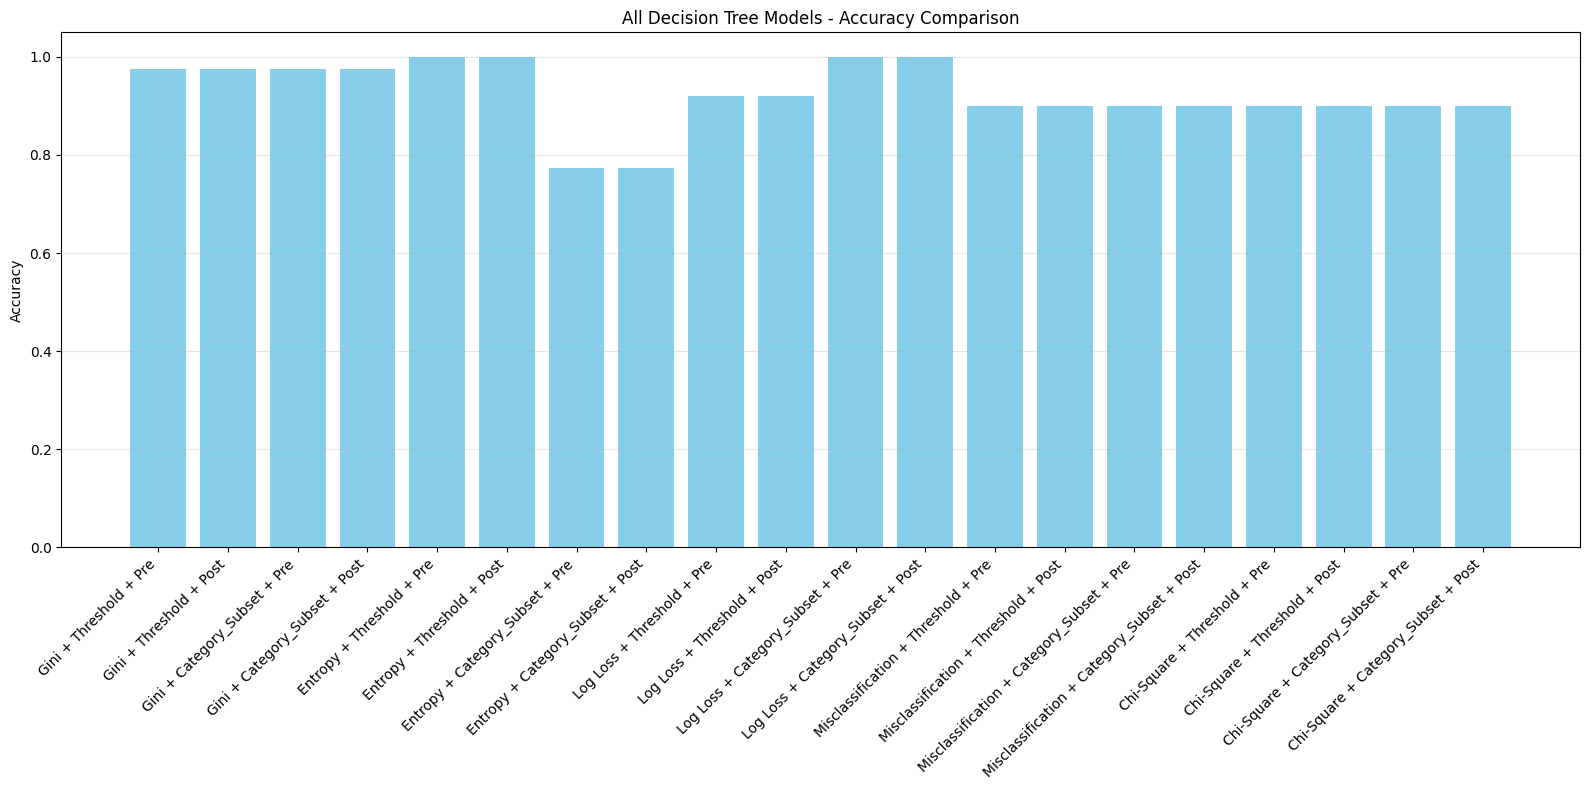

In [ ]:
# --- Plot 1: All Models Accuracy Comparison ---
plt.figure(figsize=(16, 8))
plt.bar(all_names, all_accuracies, color='skyblue')
plt.ylabel("Accuracy")
plt.title("All Decision Tree Models - Accuracy Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

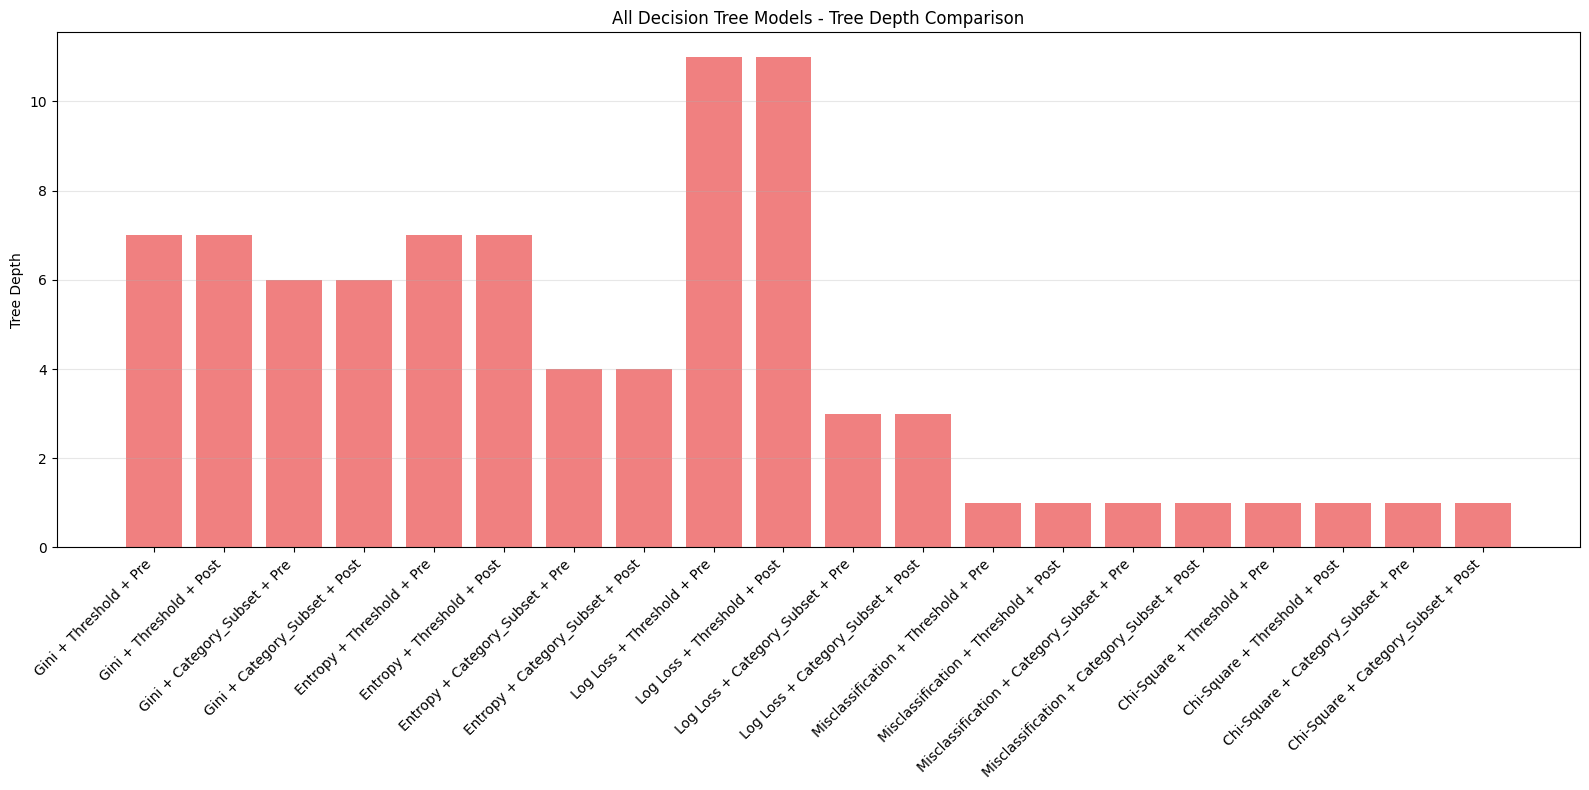

In [ ]:
# --- Plot 2: All Models Tree Depth Comparison ---
plt.figure(figsize=(16, 8))
plt.bar(all_names, all_depths, color='lightcoral')
plt.ylabel("Tree Depth")
plt.title("All Decision Tree Models - Tree Depth Comparison")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

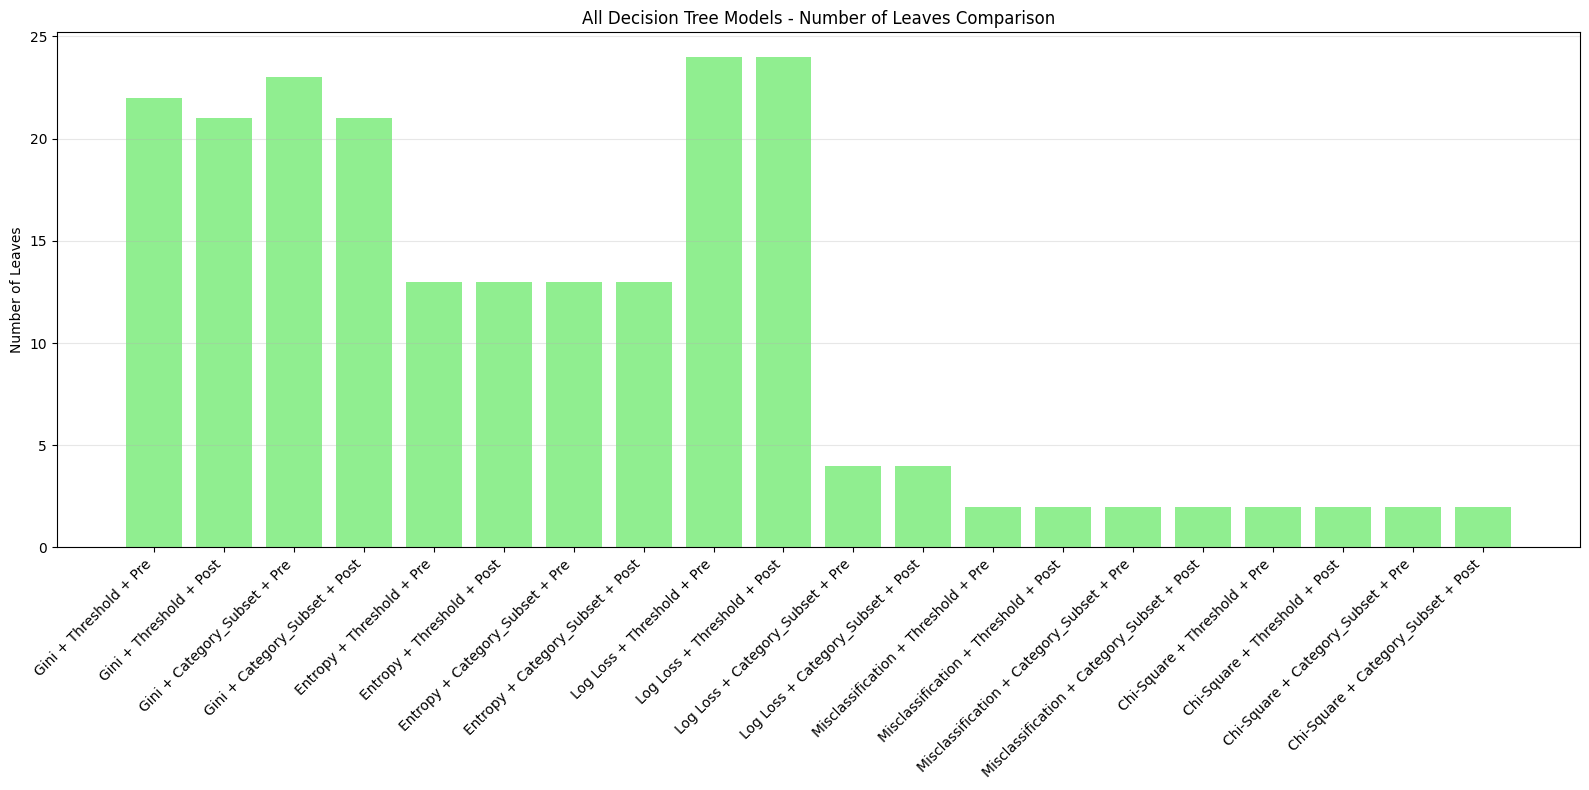

In [ ]:
# --- Plot 3: All Models Number of Leaves Comparison ---
plt.figure(figsize=(16, 8))
plt.bar(all_names, all_leaves, color='lightgreen')
plt.ylabel("Number of Leaves")
plt.title("All Decision Tree Models - Number of Leaves Comparison")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Config                                   Train Acc   Test Acc    Fit (ms)    Depth    Leaves  
Gini | Threshold | Pre                   0.9600      0.8733      555.16      10       46      
Gini | Threshold | Post                  0.9600      0.8733      1037.24     10       45      
Gini | Category_Subset | Pre             0.9244      0.9067      139.61      9        43      
Gini | Category_Subset | Post            0.9244      0.9067      107.92      9        41      
Entropy | Threshold | Pre                0.9644      0.8733      1369.17     13       46      
Entropy | Threshold | Post               0.9644      0.8733      1273.72     13       46      
Entropy | Category_Subset | Pre          0.9244      0.9067      100.97      10       41      
Entropy | Category_Subset | Post         0.9244      0.9067      96.78       10       40      
Log_loss | Threshold | Pre               0.9644      0.8733      1204.13     13       46      
Log_loss | Threshold | Post              0.9644  

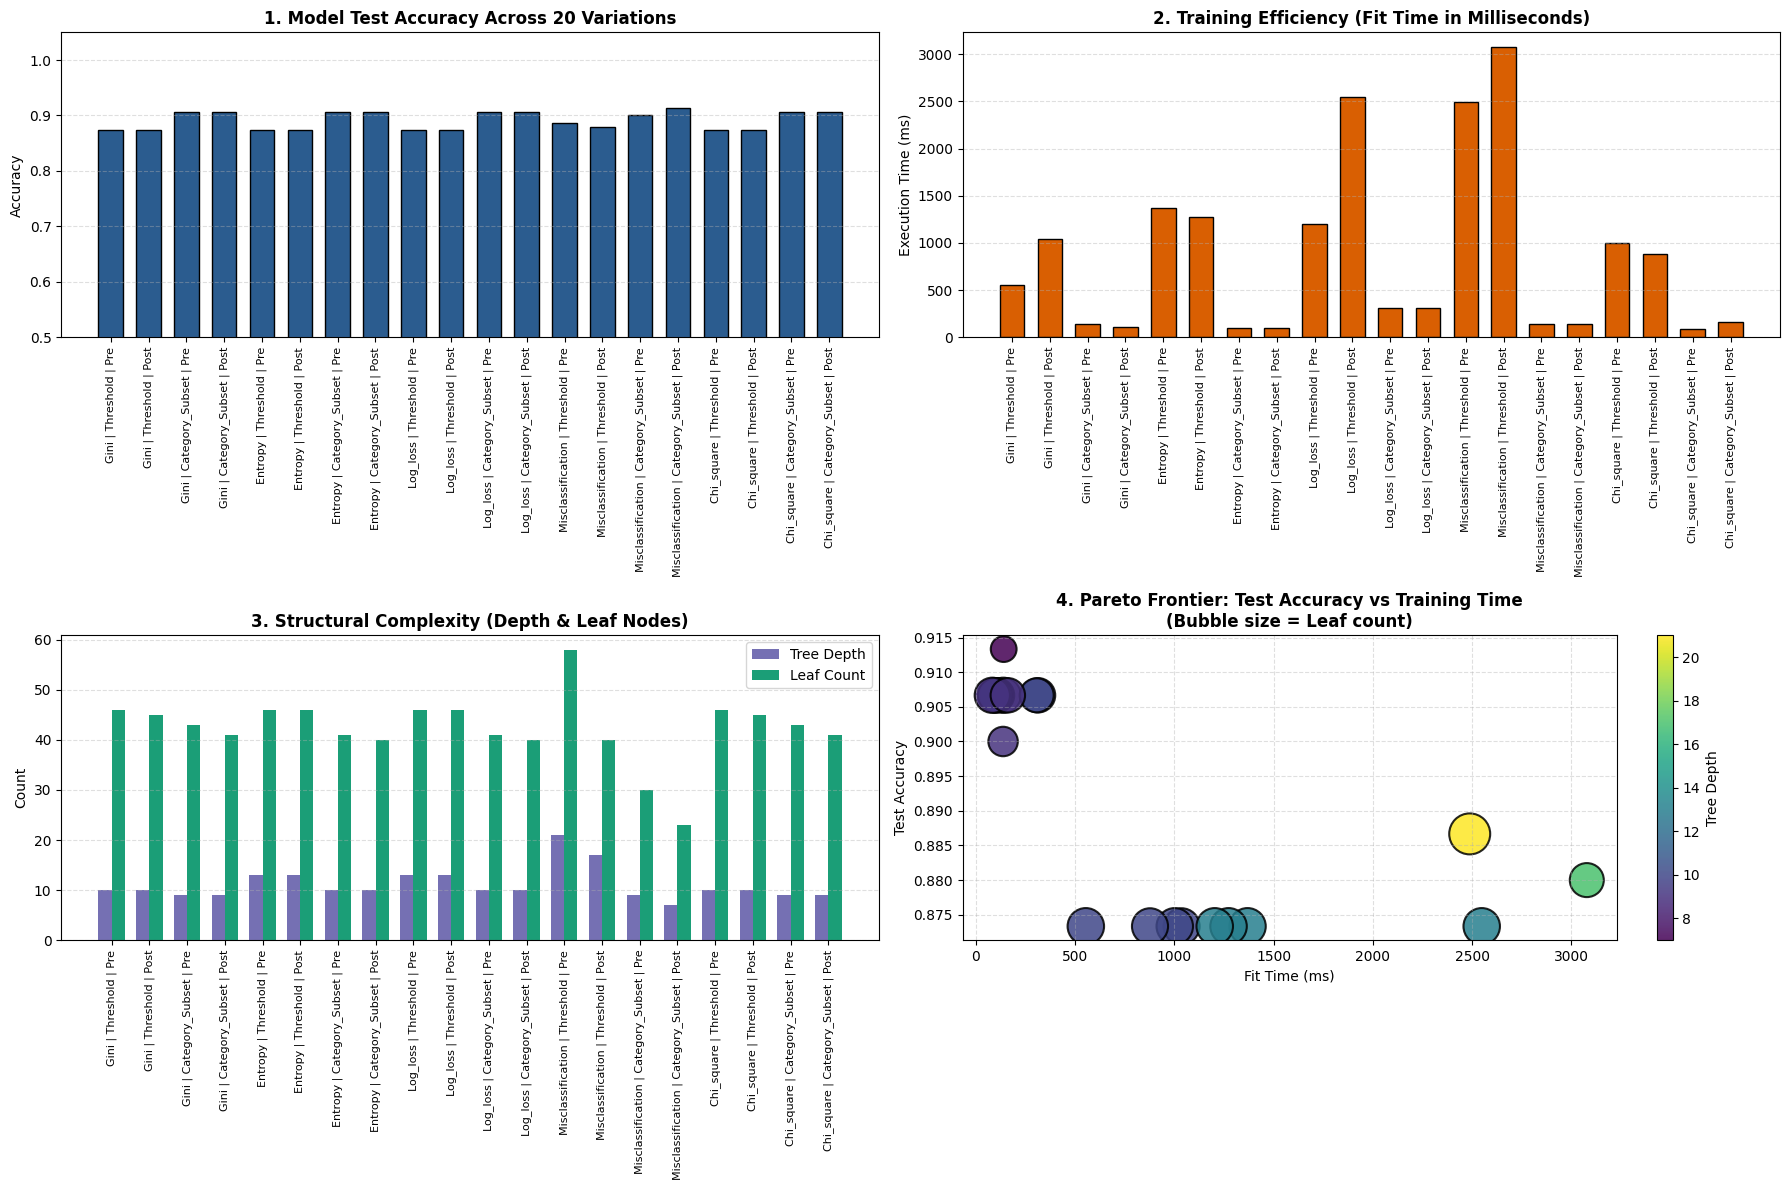

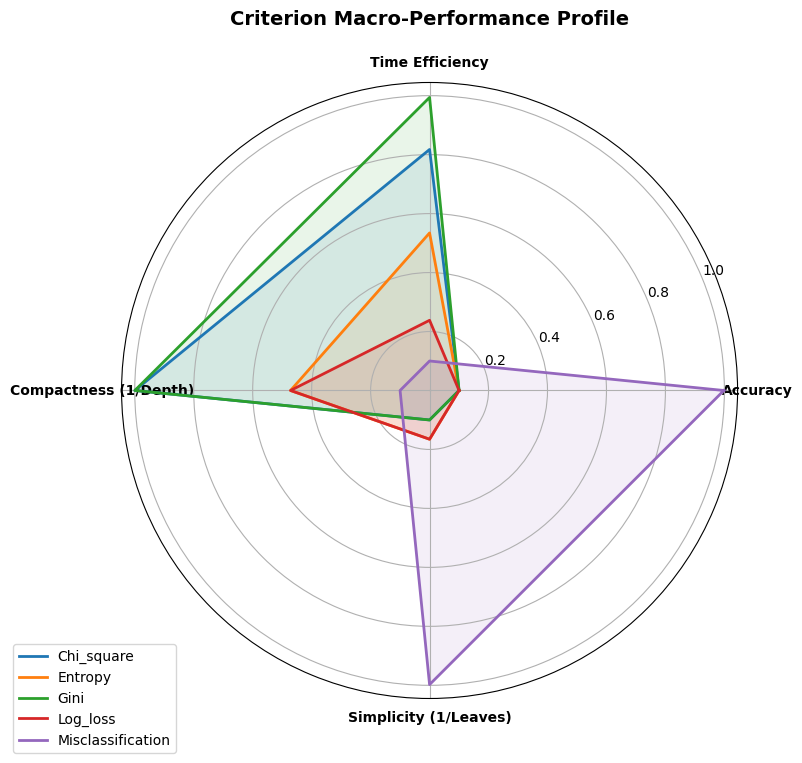

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# ============================================================
# 1. UNIFIED DECISION TREE CLASSIFIER (ALL 20 CONFIGURATIONS)
# ============================================================

class UnifiedTreeNode:
    def __init__(self, is_leaf=False, prediction=None, probabilities=None,
                 feature_index=None, threshold=None, category_subset=None,
                 left=None, right=None, impurity=0.0, n_samples=0):
        self.is_leaf = is_leaf
        self.prediction = prediction
        self.probabilities = probabilities
        self.feature_index = feature_index
        self.threshold = threshold
        self.category_subset = category_subset
        self.left = left
        self.right = right
        self.impurity = impurity
        self.n_samples = n_samples

class ComprehensiveDecisionTreeClassifier:
    def __init__(self, criterion="gini", split_strategy="Threshold", pruning="Pre",
                 max_depth=None, min_samples_split=2, min_samples_leaf=1,
                 max_features=None, max_leaf_nodes=None, min_impurity_decrease=0.0,
                 ccp_alpha=0.01, random_state=42):
        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes
        self.min_impurity_decrease = min_impurity_decrease
        self.ccp_alpha = ccp_alpha
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

        self.root_ = None
        self.classes_ = None
        self.n_classes_ = None
        self.n_features_in_ = None
        self.n_leaves_ = 0
        self.tree_depth_ = 0

    def _calc_impurity(self, y):
        n = len(y)
        if n == 0:
            return 0.0
        counts = np.bincount(y, minlength=self.n_classes_)
        p = counts / n
        p_pos = p[p > 0]

        if self.criterion == "gini":
            return 1.0 - np.sum(p ** 2)
        elif self.criterion == "entropy":
            return -np.sum(p_pos * np.log2(p_pos))
        elif self.criterion == "log_loss":
            return -np.sum(p_pos * np.log(p_pos))
        elif self.criterion == "misclassification":
            return 1.0 - np.max(p)
        elif self.criterion == "chi_square":
            return 1.0 - np.sum(p ** 2) # Parent impurity reference for chi-square
        raise ValueError(f"Unknown criterion: {self.criterion}")

    def _calc_gain(self, parent_y, left_y, right_y):
        n = len(parent_y)
        n_l, n_r = len(left_y), len(right_y)
        if n_l == 0 or n_r == 0:
            return 0.0

        if self.criterion == "chi_square":
            obs = np.array([
                np.bincount(left_y, minlength=self.n_classes_),
                np.bincount(right_y, minlength=self.n_classes_)
            ], dtype=float)
            row_t = obs.sum(axis=1, keepdims=True)
            col_t = obs.sum(axis=0, keepdims=True)
            exp = (row_t * col_t) / n
            mask = exp > 0
            return np.sum(((obs[mask] - exp[mask]) ** 2) / exp[mask])
        else:
            p_imp = self._calc_impurity(parent_y)
            w_imp = (n_l / n) * self._calc_impurity(left_y) + (n_r / n) * self._calc_impurity(right_y)
            return p_imp - w_imp

    def _select_features(self):
        feats = np.arange(self.n_features_in_)
        if self.max_features is None:
            return feats
        k = min(self.max_features, self.n_features_in_) if isinstance(self.max_features, int) else self.n_features_in_
        return self.rng.choice(feats, size=k, replace=False)

    def _find_best_split(self, X, y):
        best_gain = -np.inf
        best_f, best_val, best_l_mask, best_r_mask = None, None, None, None

        for f in self._select_features():
            col = X[:, f]
            if self.split_strategy == "Threshold":
                vals = col.astype(float)
                u_vals = np.unique(vals)
                if len(u_vals) <= 1:
                    continue
                thresholds = (u_vals[:-1] + u_vals[1:]) / 2.0
                for th in thresholds:
                    l_m = vals <= th
                    r_m = ~l_m
                    if np.sum(l_m) < self.min_samples_leaf or np.sum(r_m) < self.min_samples_leaf:
                        continue
                    gain = self._calc_gain(y, y[l_m], y[r_m])
                    if gain > best_gain:
                        best_gain, best_f, best_val, best_l_mask, best_r_mask = gain, f, th, l_m, r_m
            else:
                cats = np.unique(col)
                if len(cats) <= 1:
                    continue
                from itertools import combinations
                subsets = []
                for r in range(1, len(cats)//2 + 1):
                    for combo in combinations(cats, r):
                        if r == len(cats) - r and cats[0] not in combo:
                            continue
                        subsets.append(set(combo))
                for s in subsets:
                    l_m = np.isin(col, list(s))
                    r_m = ~l_m
                    if np.sum(l_m) < self.min_samples_leaf or np.sum(r_m) < self.min_samples_leaf:
                        continue
                    gain = self._calc_gain(y, y[l_m], y[r_m])
                    if gain > best_gain:
                        best_gain, best_f, best_val, best_l_mask, best_r_mask = gain, f, s, l_m, r_m

        return best_gain, best_f, best_val, best_l_mask, best_r_mask

    def _build_tree(self, X, y, depth=0):
        n_samples = len(y)
        counts = np.bincount(y, minlength=self.n_classes_)
        pred = np.argmax(counts)
        probs = counts / n_samples if n_samples > 0 else np.zeros(self.n_classes_)
        imp = self._calc_impurity(y)

        node = UnifiedTreeNode(is_leaf=True, prediction=pred, probabilities=probs,
                               impurity=imp, n_samples=n_samples)
        self.n_leaves_ += 1
        self.tree_depth_ = max(self.tree_depth_, depth)

        if len(np.unique(y)) <= 1 or n_samples < self.min_samples_split:
            return node
        if self.pruning == "Pre":
            if self.max_depth is not None and depth >= self.max_depth:
                return node
            if self.max_leaf_nodes is not None and self.n_leaves_ >= self.max_leaf_nodes:
                return node

        gain, f_idx, s_val, l_mask, r_mask = self._find_best_split(X, y)
        if f_idx is None or (self.pruning == "Pre" and gain < self.min_impurity_decrease):
            return node

        self.n_leaves_ -= 1
        node.is_leaf = False
        node.feature_index = f_idx
        if self.split_strategy == "Threshold":
            node.threshold = s_val
        else:
            node.category_subset = s_val

        node.left = self._build_tree(X[l_mask], y[l_mask], depth + 1)
        node.right = self._build_tree(X[r_mask], y[r_mask], depth + 1)
        return node

    def _post_prune(self, node):
        if node.is_leaf:
            return node.n_samples * node.impurity, 1
        l_risk, l_leaves = self._post_prune(node.left)
        r_risk, r_leaves = self._post_prune(node.right)
        sub_risk = l_risk + r_risk
        sub_leaves = l_leaves + r_leaves

        sub_cost = sub_risk + self.ccp_alpha * sub_leaves
        leaf_cost = (node.n_samples * node.impurity) + self.ccp_alpha

        if leaf_cost <= sub_cost:
            node.is_leaf = True
            node.left, node.right = None, None
            node.threshold, node.category_subset, node.feature_index = None, None, None
            return node.n_samples * node.impurity, 1
        return sub_risk, sub_leaves

    def _calculate_stats(self, node, depth=0):
        if node is None:
            return 0, 0
        if node.is_leaf:
            return 1, depth
        l_leaf, l_depth = self._calculate_stats(node.left, depth + 1)
        r_leaf, r_depth = self._calculate_stats(node.right, depth + 1)
        return l_leaf + r_leaf, max(l_depth, r_depth)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.n_features_in_ = X.shape[1]
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        self.n_leaves_ = 0
        self.tree_depth_ = 0

        y_enc = np.array([np.where(self.classes_ == val)[0][0] for val in y])
        self.root_ = self._build_tree(X, y_enc, depth=0)

        if self.pruning == "Post":
            self._post_prune(self.root_)
        self.n_leaves_, self.tree_depth_ = self._calculate_stats(self.root_)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf:
            return node.prediction
        val = x[node.feature_index]
        if self.split_strategy == "Threshold":
            return self._predict_one(x, node.left if float(val) <= node.threshold else node.right)
        else:
            return self._predict_one(x, node.left if val in node.category_subset else node.right)

    def predict(self, X):
        X = np.asarray(X)
        preds = [self._predict_one(x, self.root_) for x in X]
        return self.classes_[preds]

    def score(self, X, y):
        return np.mean(self.predict(X) == np.asarray(y))


# ============================================================
# 2. BENCHMARKING DATASET GENERATION
# ============================================================

np.random.seed(42)
n_samples = 600

# Continuous data for Threshold models
X_num, y_num = make_classification(n_samples=n_samples, n_features=4, n_informative=3,
                                   n_redundant=1, n_clusters_per_class=1, random_state=42)

# Discrete ordinal/categorical data for Category_Subset models
X_cat = np.digitize(X_num, bins=[-1.0, -0.2, 0.5, 1.2]).astype(str)

X_train_num, X_test_num, y_train, y_test = train_test_split(X_num, y_num, test_size=0.25, random_state=42)
X_train_cat, X_test_cat, _, _ = train_test_split(X_cat, y_num, test_size=0.25, random_state=42)


# ============================================================
# 3. RUN ALL 20 CONFIGURATIONS & COLLECT METRICS
# ============================================================

criteria = ["gini", "entropy", "log_loss", "misclassification", "chi_square"]
strategies = ["Threshold", "Category_Subset"]
prunings = ["Pre", "Post"]

benchmark_results = []

for crit in criteria:
    for strat in strategies:
        for prune in prunings:
            name = f"{crit.capitalize()} | {strat} | {prune}"

            # Select proper dataset representation
            X_tr = X_train_num if strat == "Threshold" else X_train_cat
            X_te = X_test_num if strat == "Threshold" else X_test_cat

            model = ComprehensiveDecisionTreeClassifier(
                criterion=crit,
                split_strategy=strat,
                pruning=prune,
                min_samples_split=4,
                min_samples_leaf=2,
                ccp_alpha=0.015,
                random_state=42
            )

            # Measure Training Time (Efficiency)
            t0 = time.perf_counter()
            model.fit(X_tr, y_train)
            fit_time_ms = (time.perf_counter() - t0) * 1000

            # Measure Inference Latency
            t0 = time.perf_counter()
            test_acc = model.score(X_te, y_test)
            inference_time_ms = (time.perf_counter() - t0) * 1000
            train_acc = model.score(X_tr, y_train)

            benchmark_results.append({
                "Configuration": name,
                "Criterion": crit.capitalize(),
                "Strategy": strat,
                "Pruning": prune,
                "Train Acc": train_acc,
                "Test Acc": test_acc,
                "Generalization Gap": train_acc - test_acc,
                "Fit Time (ms)": fit_time_ms,
                "Inference (ms)": inference_time_ms,
                "Depth": model.tree_depth_,
                "Leaves": model.n_leaves_
            })

df_results = pd.DataFrame(benchmark_results)

# Display tabular results
print("\n" + "="*110)
print(f"{'Config':<40} {'Train Acc':<11} {'Test Acc':<11} {'Fit (ms)':<11} {'Depth':<8} {'Leaves':<8}")
print("="*110)
for _, r in df_results.iterrows():
    print(f"{r['Configuration']:<40} {r['Train Acc']:<11.4f} {r['Test Acc']:<11.4f} {r['Fit Time (ms)']:<11.2f} {r['Depth']:<8} {r['Leaves']:<8}")
print("="*110)


# ============================================================
# 4. COMPREHENSIVE 4-PANEL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
x_idx = np.arange(len(df_results))
colors = plt.cm.tab20(np.linspace(0, 1, 20))

# Plot 1: Test Accuracy
axes[0, 0].bar(x_idx, df_results["Test Acc"], color="#2b5c8f", width=0.65, edgecolor="black")
axes[0, 0].set_title("1. Model Test Accuracy Across 20 Variations", fontweight="bold")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_xticks(x_idx)
axes[0, 0].set_xticklabels(df_results["Configuration"], rotation=90, fontsize=8)
axes[0, 0].set_ylim(0.5, 1.05)
axes[0, 0].grid(axis="y", linestyle="--", alpha=0.4)

# Plot 2: Training Latency (Efficiency)
axes[0, 1].bar(x_idx, df_results["Fit Time (ms)"], color="#d95f02", width=0.65, edgecolor="black")
axes[0, 1].set_title("2. Training Efficiency (Fit Time in Milliseconds)", fontweight="bold")
axes[0, 1].set_ylabel("Execution Time (ms)")
axes[0, 1].set_xticks(x_idx)
axes[0, 1].set_xticklabels(df_results["Configuration"], rotation=90, fontsize=8)
axes[0, 1].grid(axis="y", linestyle="--", alpha=0.4)

# Plot 3: Tree Complexity (Depth vs Number of Leaves)
w = 0.35
axes[1, 0].bar(x_idx - w/2, df_results["Depth"], width=w, label="Tree Depth", color="#7570b3")
axes[1, 0].bar(x_idx + w/2, df_results["Leaves"], width=w, label="Leaf Count", color="#1b9e77")
axes[1, 0].set_title("3. Structural Complexity (Depth & Leaf Nodes)", fontweight="bold")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_xticks(x_idx)
axes[1, 0].set_xticklabels(df_results["Configuration"], rotation=90, fontsize=8)
axes[1, 0].legend()
axes[1, 0].grid(axis="y", linestyle="--", alpha=0.4)

# Plot 4: Pareto Efficiency (Accuracy vs Training Latency)
scatter = axes[1, 1].scatter(df_results["Fit Time (ms)"], df_results["Test Acc"],
                             c=df_results["Depth"], s=df_results["Leaves"] * 15,
                             cmap="viridis", alpha=0.85, edgecolors="k", linewidths=1.5)
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label("Tree Depth")
axes[1, 1].set_title("4. Pareto Frontier: Test Accuracy vs Training Time\n(Bubble size = Leaf count)", fontweight="bold")
axes[1, 1].set_xlabel("Fit Time (ms)")
axes[1, 1].set_ylabel("Test Accuracy")
axes[1, 1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


# ============================================================
# 5. RADAR (SPIDER) CHART: MACRO COMPARISON BY CRITERION
# ============================================================

crit_summary = df_results.groupby("Criterion").agg({
    "Test Acc": "mean",
    "Fit Time (ms)": lambda x: 1 / (np.mean(x) + 1e-5),  # Inverted for efficiency
    "Depth": lambda x: 1 / np.mean(x),                   # Compactness (lower depth is better)
    "Leaves": lambda x: 1 / np.mean(x)                   # Simplicity (fewer leaves is better)
})

# Normalize [0.1, 1.0] for radar scaling
crit_norm = (crit_summary - crit_summary.min()) / (crit_summary.max() - crit_summary.min() + 1e-5) * 0.9 + 0.1

categories = ["Accuracy", "Time Efficiency", "Compactness (1/Depth)", "Simplicity (1/Leaves)"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories, size=10, fontweight="bold")

for idx, row in crit_norm.iterrows():
    vals = row.values.flatten().tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, linestyle="solid", label=idx)
    ax.fill(angles, vals, alpha=0.1)

plt.title("Criterion Macro-Performance Profile", size=14, y=1.08, fontweight="bold")
plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1))
plt.show()